# Home Loan Default Prediction

## PRCP-1006 – Home Loan Default Prediction

### Domain: Banking

## 1. Problem Statement

The objective of this project is to perform a complete data analysis on the given Home Credit dataset and build a predictive machine learning model to identify customers who are likely to default on a loan.

The project aims to:

- Understand the characteristics of loan applicants.
- Perform exploratory data analysis to identify important patterns.
- Clean and preprocess the data.
- Engineer meaningful features from the available historical datasets.
- Build multiple machine learning classification models.
- Evaluate and compare the performance of different models.
- Identify important factors associated with loan default.

## 2. Business Understanding

Loan default is an important concern for financial institutions because approving loans for customers who are likely to default can result in financial losses.

A predictive model can help a financial institution assess the risk associated with loan applicants by analyzing their demographic information, financial information, previous credit history, previous loan applications and repayment behaviour.

The objective is not only to predict loan default but also to understand the factors that are associated with higher default risk.

# Importing libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


# Load the datasets

## Dataset Overview

The project uses multiple datasets containing information about current loan applications, previous credit history, previous loan applications, repayment behavior, POS and cash loan history, and credit card history.

The main `application_train` dataset contains the target variable, where `1` represents a defaulter and `0` represents a non-defaulter. The historical datasets provide additional information that can be aggregated at the customer level and combined with the main application data.


In [2]:
data_path = ""

application_train = pd.read_csv(data_path + "application_train.csv")
bureau = pd.read_csv(data_path + "bureau.csv")
bureau_balance = pd.read_csv(data_path + "bureau_balance.csv")
credit_card_balance = pd.read_csv(data_path + "credit_card_balance.csv")
installments_payments = pd.read_csv(data_path + "installments_payments.csv")
pos_cash_balance = pd.read_csv(data_path + "POS_CASH_balance.csv")
previous_application = pd.read_csv(data_path + "previous_application.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


# Checkpoints

In [3]:
datasets = {
    "application_train": application_train,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "credit_card_balance": credit_card_balance,
    "installments_payments": installments_payments,
    "pos_cash_balance": pos_cash_balance,
    "previous_application": previous_application
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

application_train: (307511, 122)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
credit_card_balance: (3840312, 23)
installments_payments: (13605401, 8)
pos_cash_balance: (10001358, 8)
previous_application: (1670214, 37)


# Understanding the primary dataset
## primary dataset is application_train

In [4]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
application_train.shape

(307511, 122)

In [6]:
application_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [7]:
application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


# Target checking

In [8]:
application_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [9]:
application_train['TARGET'].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

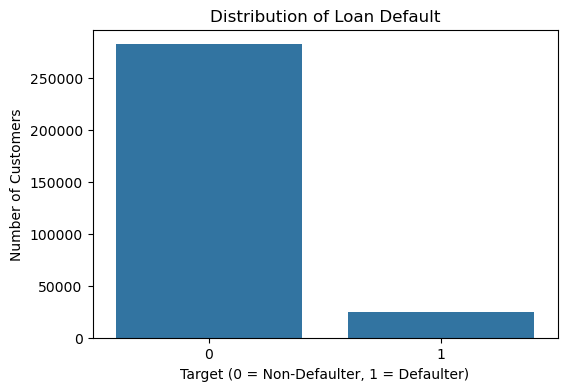

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(data=application_train, x='TARGET')

plt.title('Distribution of Loan Default')
plt.xlabel('Target (0 = Non-Defaulter, 1 = Defaulter)')
plt.ylabel('Number of Customers')

plt.show()

## The project defines TARGET as:

0 → Not Defaulter
1 → Defaulter

This target distribution will be especially important later when we handle class imbalance.

In [11]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

application_train: (307511, 122)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
credit_card_balance: (3840312, 23)
installments_payments: (13605401, 8)
pos_cash_balance: (10001358, 8)
previous_application: (1670214, 37)


In [12]:
application_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

### Observation

The dataset contains 307,511 loan applications. Among these, 282,686 customers (91.93%) are non-defaulters, while 24,825 customers (8.07%) are defaulters.

This indicates a significant class imbalance in the target variable, with non-defaulters forming the majority class. Therefore, class imbalance will need to be considered during model building and evaluation.

## Missing Values

In [13]:
missing_values = application_train.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False).head(20)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

In [14]:
#checking duplicate records
application_train.duplicated().sum()

np.int64(0)

In [15]:
#checking data types
application_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [16]:
# checking Unique values
application_train.nunique().sort_values(ascending=False).head(20)

SK_ID_CURR                307511
EXT_SOURCE_2              119831
EXT_SOURCE_1              114584
DAYS_BIRTH                 17460
DAYS_REGISTRATION          15688
AMT_ANNUITY                13672
DAYS_EMPLOYED              12574
DAYS_ID_PUBLISH             6168
AMT_CREDIT                  5603
LIVINGAREA_MODE             5301
LIVINGAREA_MEDI             5281
LIVINGAREA_AVG              5199
TOTALAREA_MODE              5116
BASEMENTAREA_MODE           3841
BASEMENTAREA_AVG            3780
DAYS_LAST_PHONE_CHANGE      3773
BASEMENTAREA_MEDI           3772
LANDAREA_MODE               3563
LANDAREA_MEDI               3560
LANDAREA_AVG                3527
dtype: int64

## EDA

## Numerical and Categorical Variables

In [17]:
numeric_cols = application_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = application_train.select_dtypes(include='object').columns.tolist()

print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 106
Number of categorical columns: 16


In [18]:
print("Numerical columns:")
print(numeric_cols)

Numerical columns:
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUA

In [19]:
print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


## Missing Value Analysis

In [20]:
missing = pd.DataFrame({
    'Missing_Count': application_train.isnull().sum(),
    'Missing_Percentage': application_train.isnull().mean() * 100
})

missing = missing.sort_values(
    by='Missing_Percentage',
    ascending=False
)

missing.head(20)

,Missing_Count,Missing_Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


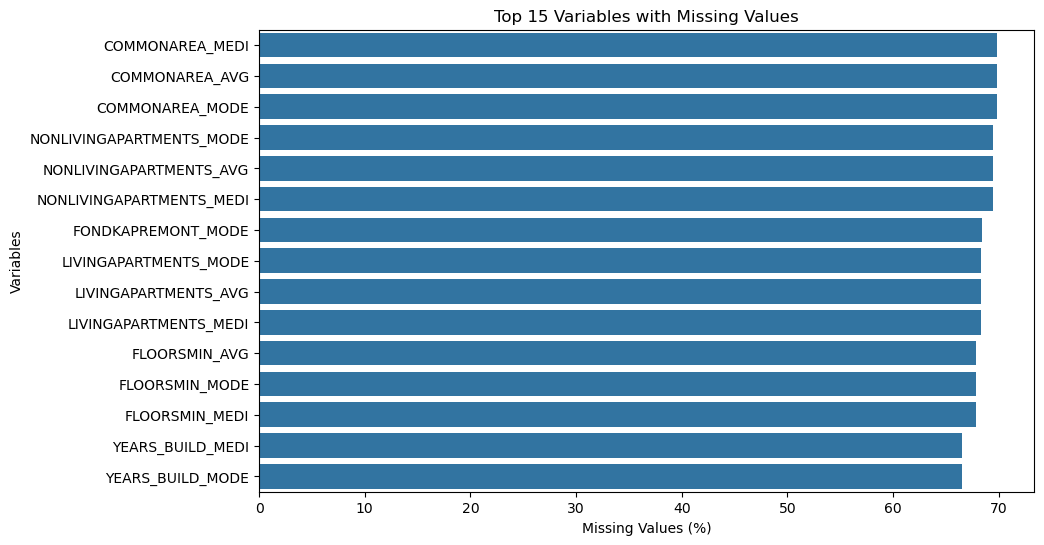

In [21]:
#Visualize the top missing columns
plt.figure(figsize=(10, 6))

top_missing = missing.head(15)

sns.barplot(
    x=top_missing['Missing_Percentage'],
    y=top_missing.index
)

plt.title('Top 15 Variables with Missing Values')
plt.xlabel('Missing Values (%)')
plt.ylabel('Variables')

plt.show()

### This tells us which variables have substantial missing information.

## Numerical Variables

In [22]:
financial_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]

application_train[financial_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0


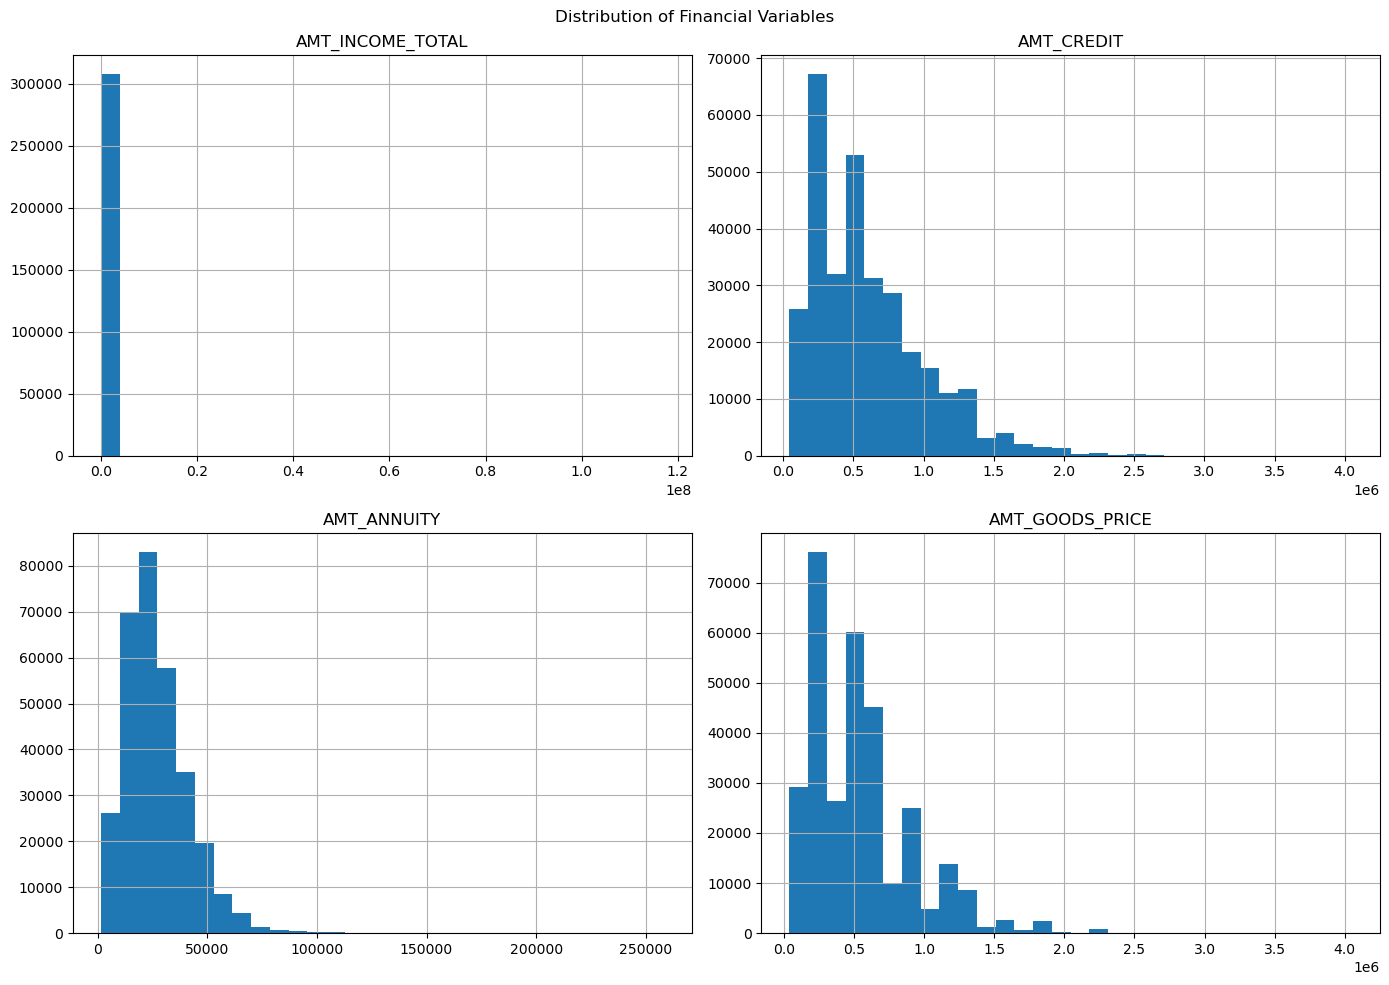

In [23]:
#distribution
application_train[financial_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle('Distribution of Financial Variables')
plt.tight_layout()
plt.show()

## Financial Variables vs Default

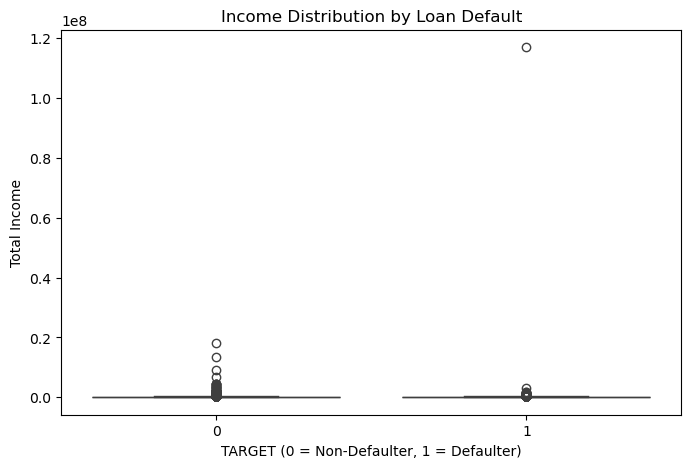

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=application_train,
    x='TARGET',
    y='AMT_INCOME_TOTAL'
)

plt.title('Income Distribution by Loan Default')
plt.xlabel('TARGET (0 = Non-Defaulter, 1 = Defaulter)')
plt.ylabel('Total Income')

plt.show()

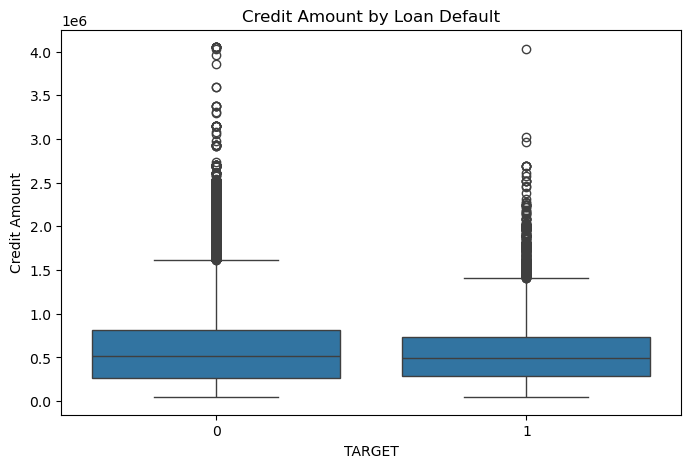

In [25]:
#Income vs Target
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=application_train,
    x='TARGET',
    y='AMT_CREDIT'
)

plt.title('Credit Amount by Loan Default')
plt.xlabel('TARGET')
plt.ylabel('Credit Amount')

plt.show()

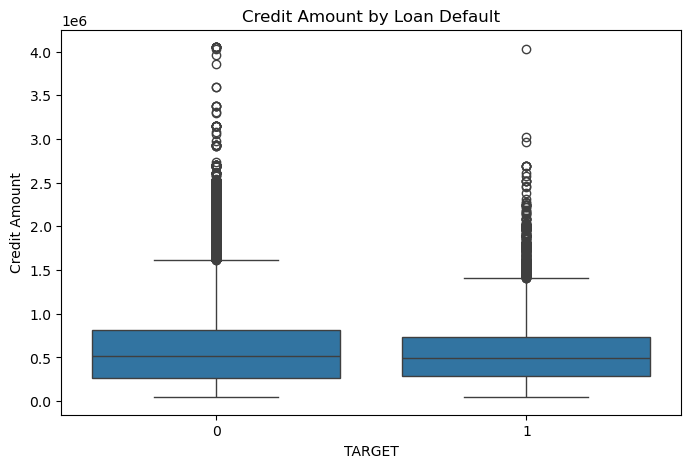

In [26]:
#Credit amount vs Target
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=application_train,
    x='TARGET',
    y='AMT_CREDIT'
)

plt.title('Credit Amount by Loan Default')
plt.xlabel('TARGET')
plt.ylabel('Credit Amount')

plt.show()

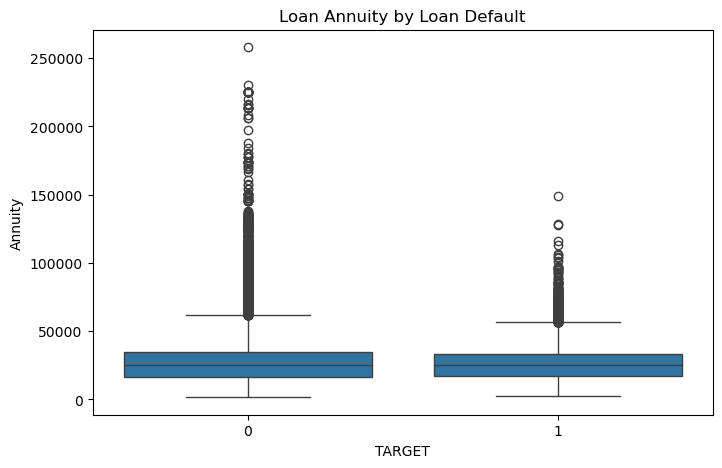

In [27]:
#Annuity vs Target
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=application_train,
    x='TARGET',
    y='AMT_ANNUITY'
)

plt.title('Loan Annuity by Loan Default')
plt.xlabel('TARGET')
plt.ylabel('Annuity')

plt.show()

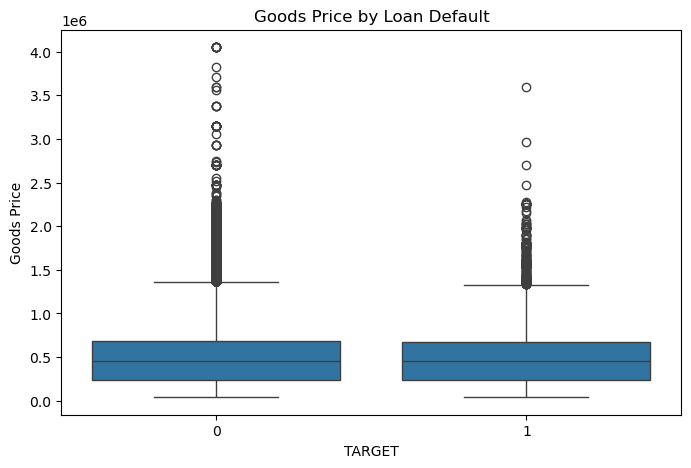

In [28]:
#Goods price vs Target
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=application_train,
    x='TARGET',
    y='AMT_GOODS_PRICE'
)

plt.title('Goods Price by Loan Default')
plt.xlabel('TARGET')
plt.ylabel('Goods Price')

plt.show()

## Age Analysis
The dataset stores age as DAYS_BIRTH, so create an understandable age variable for EDA.

In [29]:
application_train['AGE_YEARS'] = (
    -application_train['DAYS_BIRTH'] / 365
)

In [30]:
application_train['AGE_YEARS'].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE_YEARS, dtype: float64

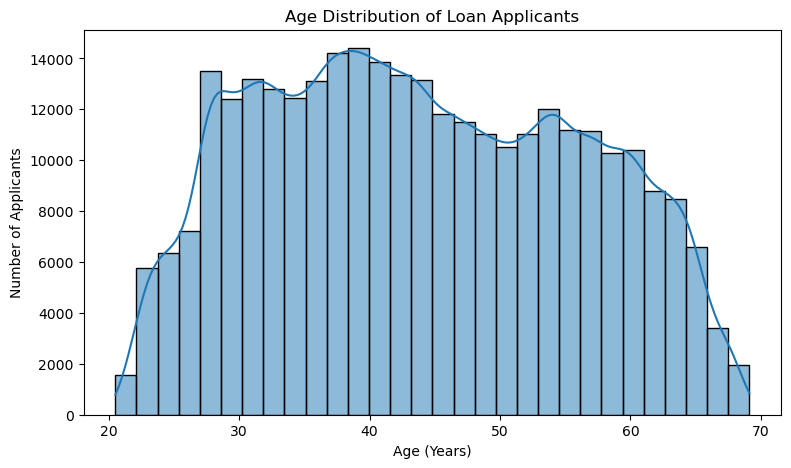

In [31]:
#Age distribution
plt.figure(figsize=(9, 5))

sns.histplot(
    data=application_train,
    x='AGE_YEARS',
    bins=30,
    kde=True
)

plt.title('Age Distribution of Loan Applicants')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Applicants')

plt.show()

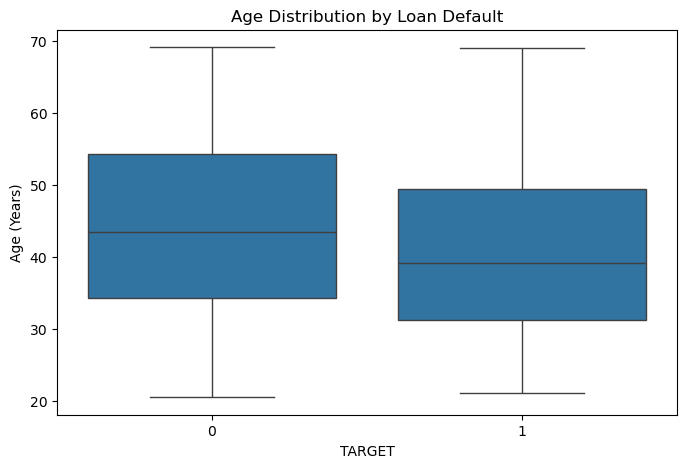

In [32]:
#Age vs Default
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=application_train,
    x='TARGET',
    y='AGE_YEARS'
)

plt.title('Age Distribution by Loan Default')
plt.xlabel('TARGET')
plt.ylabel('Age (Years)')

plt.show()

## Age Groups
Age groups are easier to interpret from a business perspective.

In [33]:
application_train['AGE_GROUP'] = pd.cut(
    application_train['AGE_YEARS'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

In [34]:
age_default = application_train.groupby(
    'AGE_GROUP',
    observed=False
)['TARGET'].agg(['count', 'sum', 'mean'])

age_default['default_rate_%'] = age_default['mean'] * 100

age_default

,count,sum,mean,default_rate_%
AGE_GROUP,,,,
18-25,12159,1496,0.123036,12.303643
26-35,72302,7717,0.106733,10.673287
36-45,84274,7083,0.084047,8.404727
46-55,70077,4946,0.070580,7.057951
56-65,60596,3281,0.054145,5.414549
65+,8103,302,0.037270,3.727015


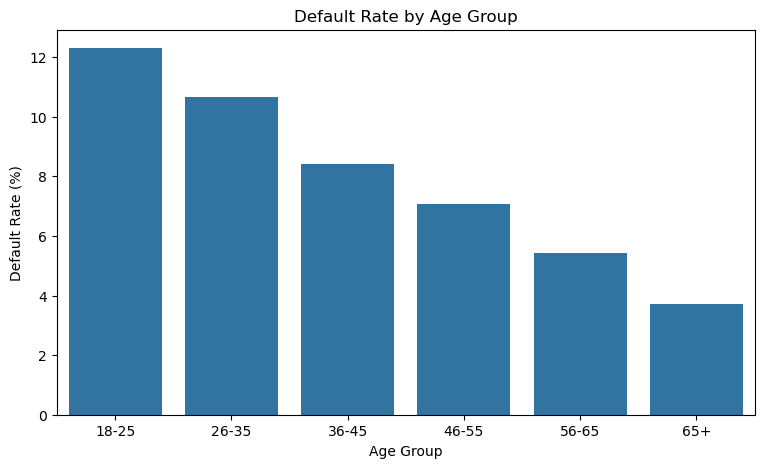

In [35]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_default.index,
    y=age_default['default_rate_%']
)

plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')

plt.show()

## Gender Analysis

In [36]:
application_train['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [37]:
gender_default = application_train.groupby(
    'CODE_GENDER'
)['TARGET'].agg(['count', 'mean'])

gender_default['default_rate_%'] = gender_default['mean'] * 100

gender_default

,count,mean,default_rate_%
CODE_GENDER,,,
F,202448,0.069993,6.999328
M,105059,0.101419,10.141920
XNA,4,0.000000,0.000000


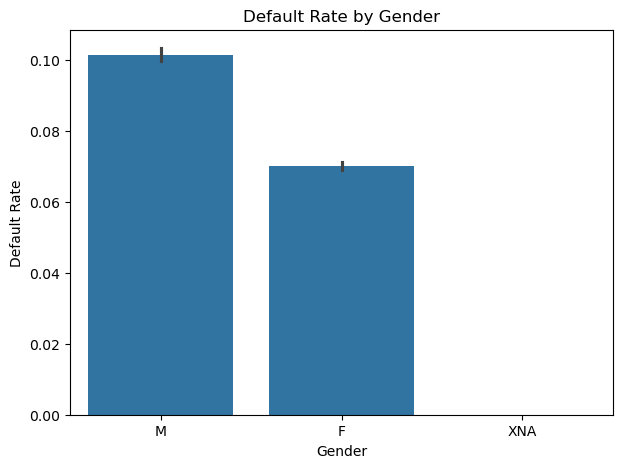

In [38]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=application_train,
    x='CODE_GENDER',
    y='TARGET'
)

plt.title('Default Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Default Rate')

plt.show()

## Education Analysis

In [39]:
application_train['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [40]:
education_default = application_train.groupby(
    'NAME_EDUCATION_TYPE'
)['TARGET'].agg(['count', 'mean'])

education_default['default_rate_%'] = (
    education_default['mean'] * 100
)

education_default.sort_values(
    'default_rate_%',
    ascending=False
)

,count,mean,default_rate_%
NAME_EDUCATION_TYPE,,,
Lower secondary,3816,0.109277,10.927673
Secondary / secondary special,218391,0.089399,8.939929
Incomplete higher,10277,0.084850,8.484966
Higher education,74863,0.053551,5.355115
Academic degree,164,0.018293,1.829268


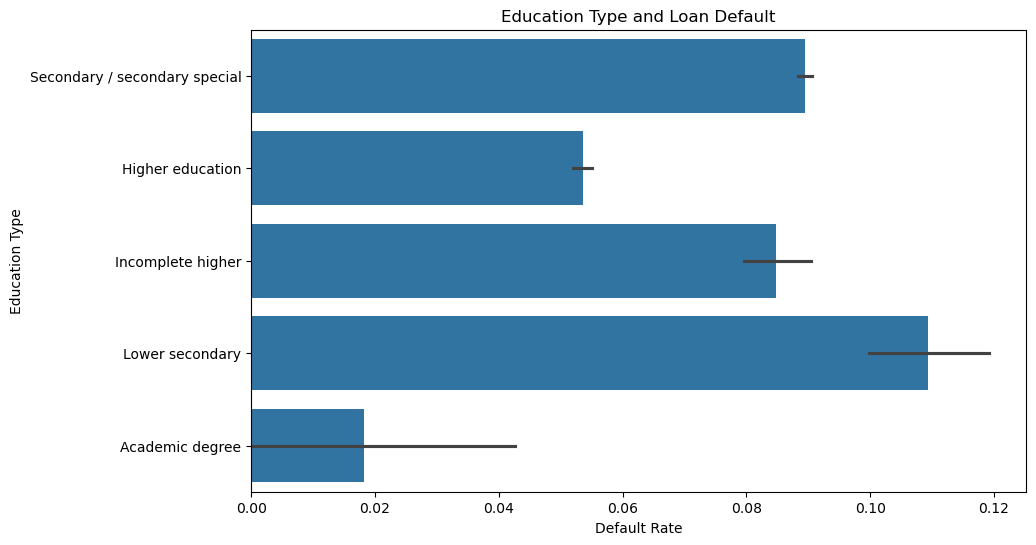

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=application_train,
    x='TARGET',
    y='NAME_EDUCATION_TYPE'
)

plt.title('Education Type and Loan Default')
plt.xlabel('Default Rate')
plt.ylabel('Education Type')

plt.show()

## Income type

In [42]:
application_train['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [43]:
income_type_default = application_train.groupby(
    'NAME_INCOME_TYPE'
)['TARGET'].agg(['count', 'mean'])

income_type_default['default_rate_%'] = (
    income_type_default['mean'] * 100
)

income_type_default.sort_values(
    'default_rate_%',
    ascending=False
)

,count,mean,default_rate_%
NAME_INCOME_TYPE,,,
Maternity leave,5,0.400000,40.000000
Unemployed,22,0.363636,36.363636
Working,158774,0.095885,9.588472
Commercial associate,71617,0.074843,7.484257
State servant,21703,0.057550,5.754965
Pensioner,55362,0.053864,5.386366
Businessman,10,0.000000,0.000000
Student,18,0.000000,0.000000


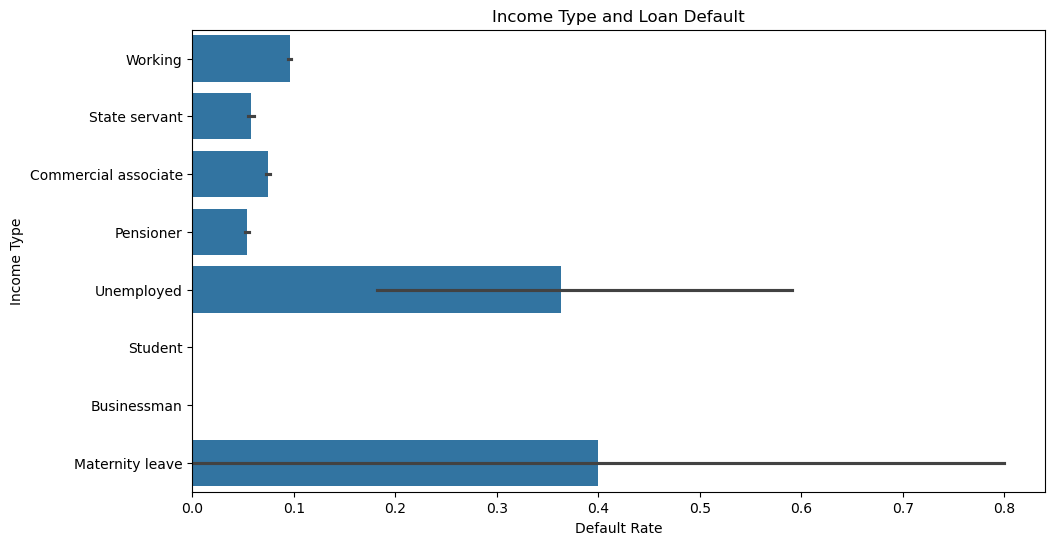

In [44]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=application_train,
    x='TARGET',
    y='NAME_INCOME_TYPE'
)

plt.title('Income Type and Loan Default')
plt.xlabel('Default Rate')
plt.ylabel('Income Type')

plt.show()

# Family Status

In [45]:
family_default = application_train.groupby(
    'NAME_FAMILY_STATUS'
)['TARGET'].agg(['count', 'mean'])

family_default['default_rate_%'] = (
    family_default['mean'] * 100
)

family_default.sort_values(
    'default_rate_%',
    ascending=False
)

,count,mean,default_rate_%
NAME_FAMILY_STATUS,,,
Civil marriage,29775,0.099446,9.944584
Single / not married,45444,0.098077,9.807675
Separated,19770,0.081942,8.194234
Married,196432,0.075599,7.559868
Widow,16088,0.058242,5.824217
Unknown,2,0.000000,0.000000


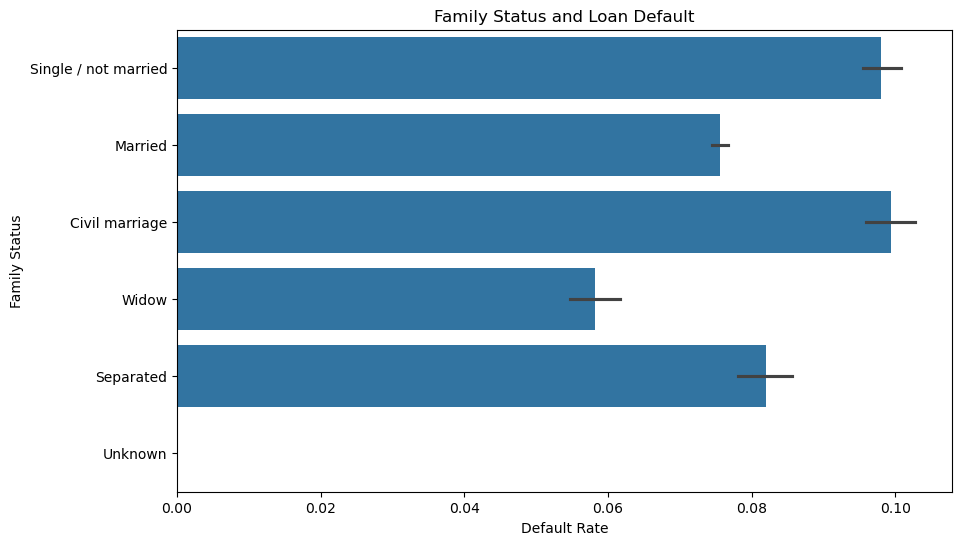

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=application_train,
    x='TARGET',
    y='NAME_FAMILY_STATUS'
)

plt.title('Family Status and Loan Default')
plt.xlabel('Default Rate')
plt.ylabel('Family Status')

plt.show()

## Employment Analysis

In [47]:
application_train['EMPLOYMENT_YEARS'] = (
    application_train['DAYS_EMPLOYED'] / -365
)

In [48]:
application_train['EMPLOYMENT_YEARS'].describe()

count    307511.000000
mean       -174.835742
std         387.056895
min       -1000.665753
25%           0.791781
50%           3.323288
75%           7.561644
max          49.073973
Name: EMPLOYMENT_YEARS, dtype: float64

In [49]:
(application_train['DAYS_EMPLOYED'] == 365243).sum()

np.int64(55374)

## External Credit Scores

In [50]:
external_cols = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

application_train[external_cols].describe()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,134133.000000,3.068510e+05,246546.000000
mean,0.502130,5.143927e-01,0.510853
std,0.211062,1.910602e-01,0.194844
min,0.014568,8.173617e-08,0.000527
25%,0.334007,3.924574e-01,0.370650
50%,0.505998,5.659614e-01,0.535276
75%,0.675053,6.636171e-01,0.669057
max,0.962693,8.549997e-01,0.896010


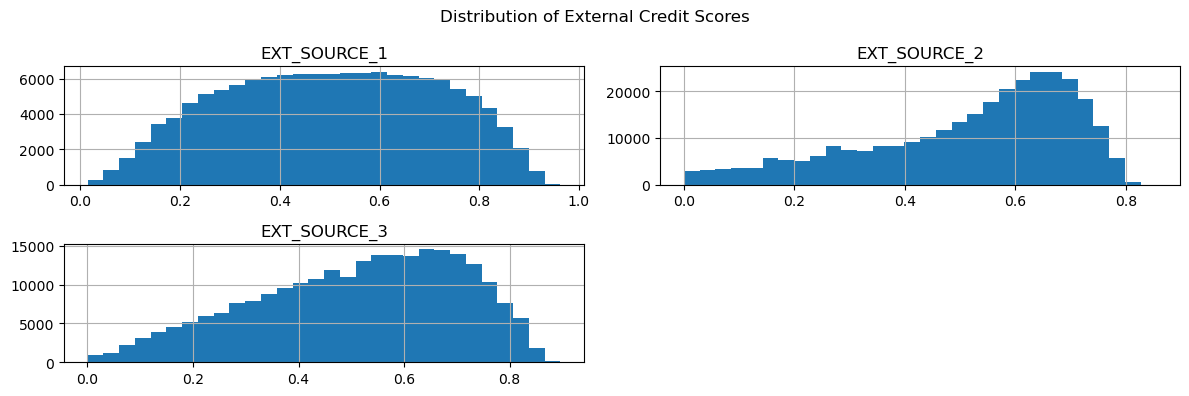

In [51]:
application_train[external_cols].hist(
    figsize=(12, 4),
    bins=30
)

plt.suptitle('Distribution of External Credit Scores')
plt.tight_layout()
plt.show()

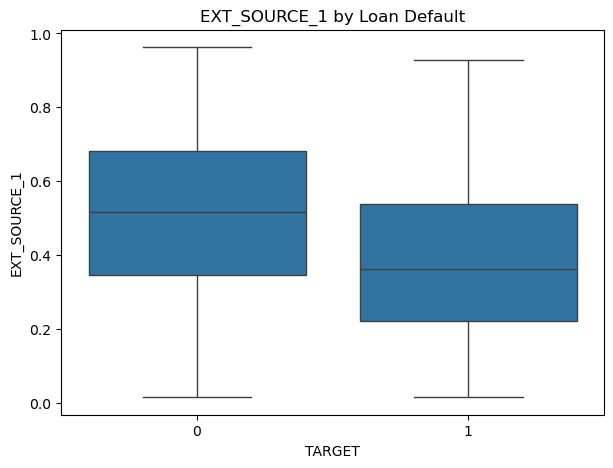

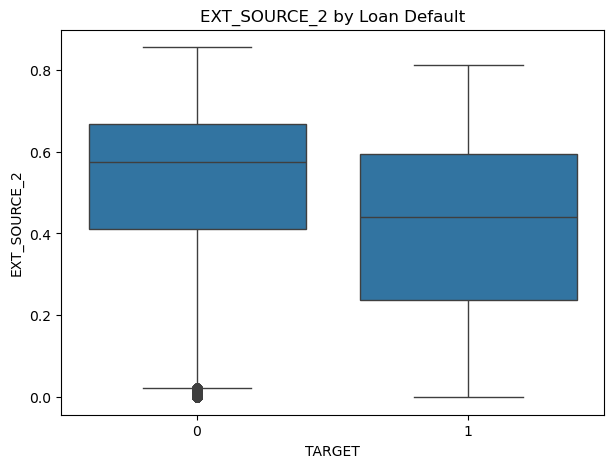

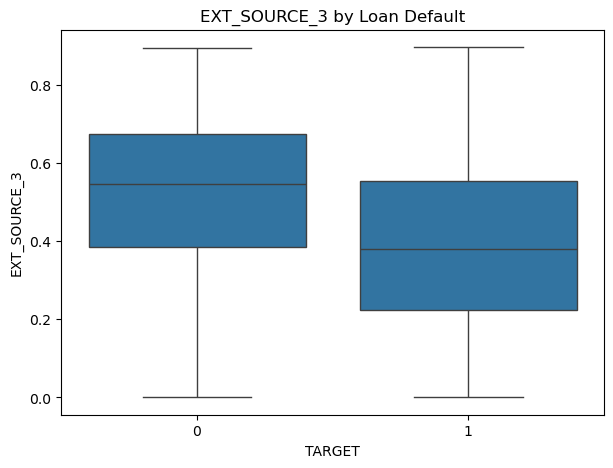

In [52]:
for col in external_cols:
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
        data=application_train,
        x='TARGET',
        y=col
    )
    
    plt.title(f'{col} by Loan Default')
    plt.xlabel('TARGET')
    plt.ylabel(col)
    
    plt.show()

## Number of Children

In [53]:
application_train['CNT_CHILDREN'].describe()

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

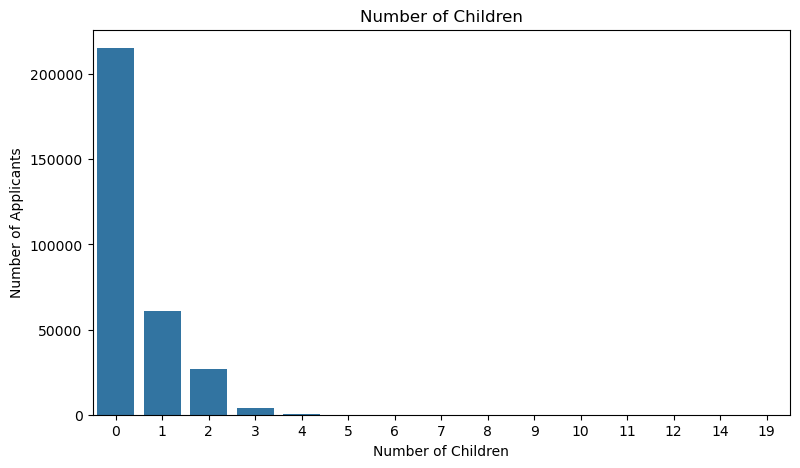

In [54]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=application_train,
    x='CNT_CHILDREN'
)

plt.title('Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Number of Applicants')

plt.show()

In [55]:
children_default = application_train.groupby(
    'CNT_CHILDREN'
)['TARGET'].mean() * 100

children_default

CNT_CHILDREN
0       7.711809
1       8.923575
2       8.721821
3       9.631423
4      12.820513
5       8.333333
6      28.571429
7       0.000000
8       0.000000
9     100.000000
10      0.000000
11    100.000000
12      0.000000
14      0.000000
19      0.000000
Name: TARGET, dtype: float64

## Housing Type

In [56]:
housing_default = application_train.groupby(
    'NAME_HOUSING_TYPE'
)['TARGET'].agg(['count', 'mean'])

housing_default['default_rate_%'] = (
    housing_default['mean'] * 100
)

housing_default.sort_values(
    'default_rate_%',
    ascending=False
)

,count,mean,default_rate_%
NAME_HOUSING_TYPE,,,
Rented apartment,4881,0.123131,12.313051
With parents,14840,0.116981,11.698113
Municipal apartment,11183,0.085397,8.539748
Co-op apartment,1122,0.079323,7.932264
House / apartment,272868,0.077957,7.795711
Office apartment,2617,0.065724,6.572411


## Contract Type

In [57]:
application_train['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

In [58]:
contract_default = application_train.groupby(
    'NAME_CONTRACT_TYPE'
)['TARGET'].mean() * 100

contract_default

NAME_CONTRACT_TYPE
Cash loans         8.345913
Revolving loans    5.478329
Name: TARGET, dtype: float64

## Correlation Analysis

In [59]:
corr = application_train[numeric_cols].corr()

In [60]:
target_corr = corr['TARGET'].sort_values(
    ascending=False
)

target_corr.head(15)

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
Name: TARGET, dtype: float64

In [61]:
target_corr = corr['TARGET'].sort_values(
    ascending=False
)

target_corr.head(15)

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
Name: TARGET, dtype: float64

In [62]:
target_corr.tail(15)

LIVINGAREA_MEDI              -0.032739
LIVINGAREA_AVG               -0.032997
FLOORSMIN_MEDI               -0.033394
FLOORSMIN_AVG                -0.033614
ELEVATORS_MEDI               -0.033863
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64

# Heatmap of important variables

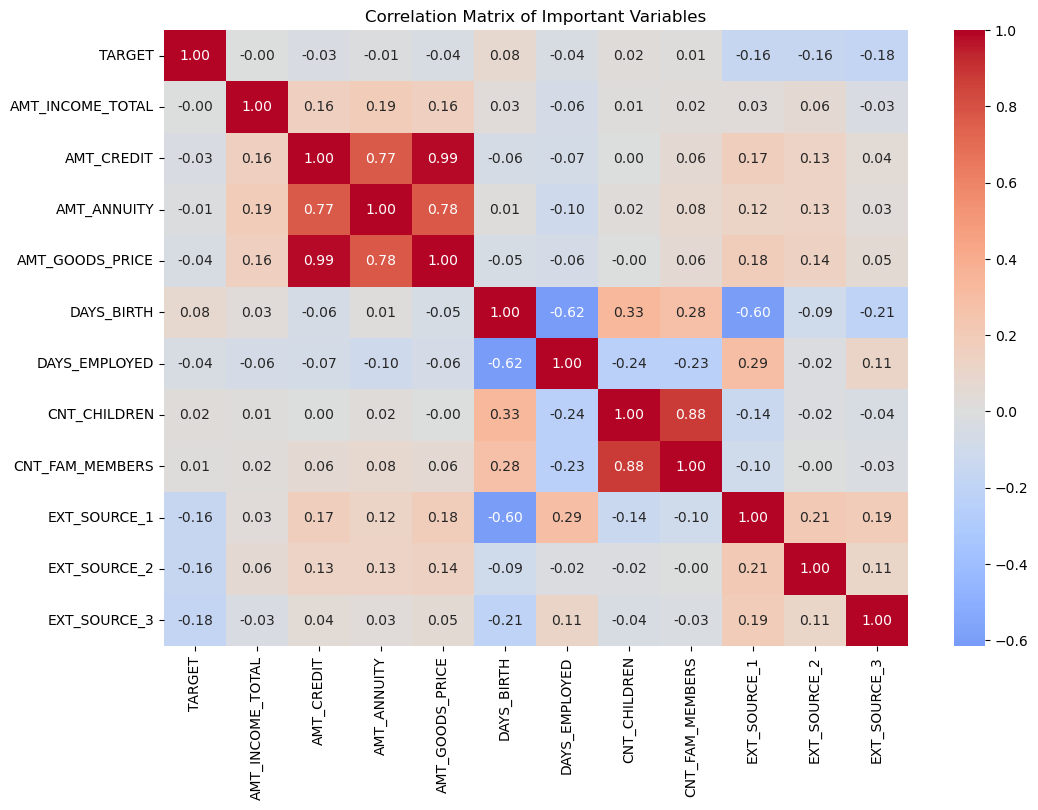

In [63]:
corr_cols = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    application_train[corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Important Variables')

plt.show()

## Outlier Analysis

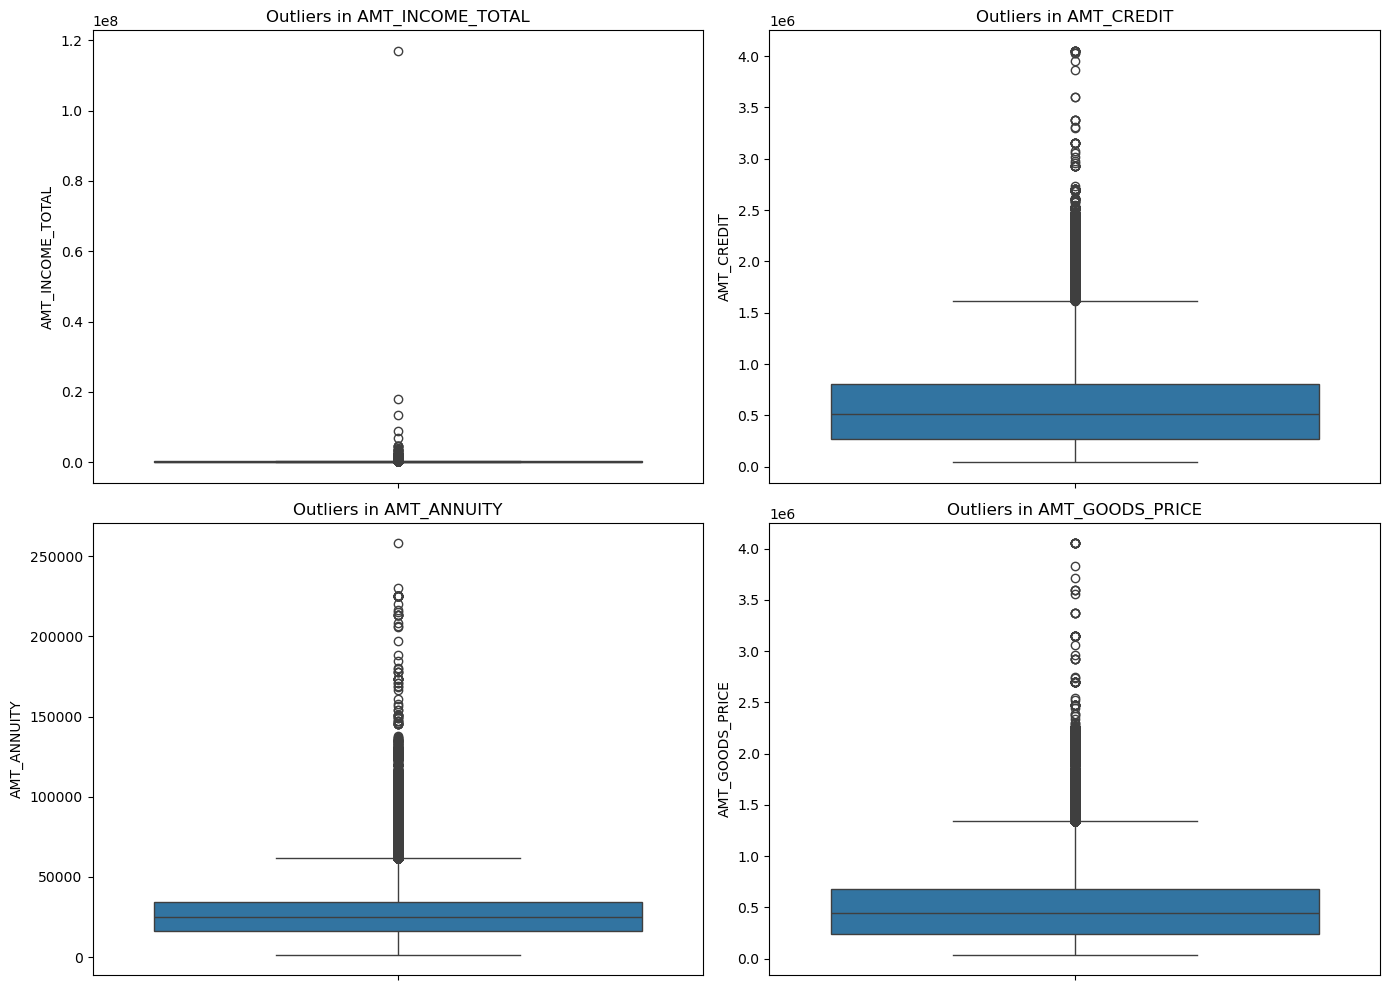

In [64]:
outlier_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(2, 2, i)
    
    sns.boxplot(
        y=application_train[col]
    )
    
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

## Top Categorical Variables

In [65]:
categorical_cols = application_train.select_dtypes(
    include='object'
).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(application_train[col].value_counts().head(10))


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    218391

## Final EDA Conclusion

## EDA Summary and Key Findings

The exploratory data analysis was performed to understand the applicant characteristics, financial attributes, employment information, demographic factors and their relationship with loan default.

### Key findings:

1. The target variable is highly imbalanced, with non-defaulters representing the majority of applications.

2. Financial variables such as income, credit amount, annuity and goods price show different distributions and contain extreme values that require further investigation during preprocessing.

3. Applicant age shows variation across the dataset, and age groups can be analyzed based on their observed default rates.

4. Categorical variables such as gender, education, income type, family status and housing type show different applicant distributions and default rates across categories.

5. Employment-related variables contain unusual values that need appropriate treatment during data preprocessing.

6. External credit score variables show useful variation and will be further evaluated as potential predictive features.

7. Several numerical variables show relationships with the target variable and with each other, which will be considered during feature selection and model building.

8. The historical datasets contain additional information about previous credit, loan applications and repayment behaviour. These datasets will be analyzed and aggregated before being incorporated into the final predictive dataset.

## Feature Engineering

Feature engineering was performed to create meaningful variables from the existing application data and historical credit information.

Derived features included age in years, employment duration, income-to-credit ratio, credit-to-income ratio, annuity-to-income ratio, credit-to-goods-price ratio, and income per family member.

Historical information from bureau, previous applications, POS/CASH balance, credit card balance, installment payments, and bureau balance datasets was aggregated at the customer level using `SK_ID_CURR` and merged with the main application dataset.

These engineered and aggregated features provide additional information about the applicant's financial profile and previous credit behavior.


In [66]:
# Create a copy of the main dataset
df = application_train.copy()

# Age in years
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

# Employment duration
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365

# Income and credit ratios
df['INCOME_CREDIT_RATIO'] = (
    df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
)

df['CREDIT_INCOME_RATIO'] = (
    df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
)

df['ANNUITY_INCOME_RATIO'] = (
    df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
)

df['CREDIT_GOODS_RATIO'] = (
    df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
)

# Income per family member
df['INCOME_PER_FAMILY_MEMBER'] = (
    df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
)

# Display new features
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,AGE_GROUP,EMPLOYMENT_YEARS,INCOME_CREDIT_RATIO,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_FAMILY_MEMBER
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,1.0,25.920548,26-35,1.745205,0.498036,2.007889,0.121978,1.158397,101250.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,45.931507,46-55,3.254795,0.208736,4.790750,0.132217,1.145199,90000.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,52.180822,46-55,0.616438,0.500000,2.000000,0.100000,1.000000,33750.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,52.068493,46-55,8.326027,0.431748,2.316167,0.219900,1.052803,45000.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,54.608219,46-55,8.323288,0.236842,4.222222,0.179963,1.000000,60750.0


In [67]:
new_features = [
    'AGE_YEARS',
    'EMPLOYMENT_YEARS',
    'INCOME_CREDIT_RATIO',
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_GOODS_RATIO',
    'INCOME_PER_FAMILY_MEMBER'
]

df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01
EMPLOYMENT_YEARS,307511.0,-174.835742,387.056895,-1000.665753,0.791781,3.323288,7.561644,4.907397e+01
INCOME_CREDIT_RATIO,307511.0,0.399670,0.507924,0.011801,0.193803,0.306272,0.495376,2.080033e+02
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_GOODS_RATIO,307233.0,1.122995,0.124045,0.150000,1.000000,1.118800,1.198000,6.000000e+00
INCOME_PER_FAMILY_MEMBER,307509.0,57482.254719,65851.657720,2647.058824,33750.000000,49500.000000,67500.000000,2.925000e+07


In [68]:
y = df['TARGET']

print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [69]:
print("df shape:", df.shape)

print("\nColumns created:")
for feature in new_features:
    print(feature, "->", feature in df.columns)

df shape: (307511, 130)

Columns created:
AGE_YEARS -> True
EMPLOYMENT_YEARS -> True
INCOME_CREDIT_RATIO -> True
CREDIT_INCOME_RATIO -> True
ANNUITY_INCOME_RATIO -> True
CREDIT_GOODS_RATIO -> True
INCOME_PER_FAMILY_MEMBER -> True


# Correct EMPLOYMENT_YEARS
In the original dataset, DAYS_EMPLOYED = 365243 represents an anomalous/special value. Let's convert it to missing first.|

In [70]:
# Replace the anomalous DAYS_EMPLOYED value with NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Recalculate employment duration in years
df['EMPLOYMENT_YEARS'] = -df['DAYS_EMPLOYED'] / 365

# Check the result
df['EMPLOYMENT_YEARS'].describe()

count    252137.000000
mean          6.531971
std           6.406466
min          -0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: EMPLOYMENT_YEARS, dtype: float64

In [71]:
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01
EMPLOYMENT_YEARS,252137.0,6.531971,6.406466,-0.000000,2.101370,4.515068,8.698630,4.907397e+01
INCOME_CREDIT_RATIO,307511.0,0.399670,0.507924,0.011801,0.193803,0.306272,0.495376,2.080033e+02
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_GOODS_RATIO,307233.0,1.122995,0.124045,0.150000,1.000000,1.118800,1.198000,6.000000e+00
INCOME_PER_FAMILY_MEMBER,307509.0,57482.254719,65851.657720,2647.058824,33750.000000,49500.000000,67500.000000,2.925000e+07


### Feature Engineering – Observation

Several meaningful features were derived from the original variables to improve the predictive information available to the machine learning models.

* `AGE_YEARS` was created from `DAYS_BIRTH` to represent the applicant's age in years.
* `EMPLOYMENT_YEARS` was derived from `DAYS_EMPLOYED` to represent employment duration.
* Financial ratio features such as income-to-credit, credit-to-income, annuity-to-income and credit-to-goods-price ratios were created to capture the applicant's financial position.
* `INCOME_PER_FAMILY_MEMBER` was created to represent the approximate income available per family member.
* The special value `365243` in `DAYS_EMPLOYED` was treated as a missing value before calculating employment duration because it does not represent a realistic employment period.

These engineered variables will be used along with the original applicant information during preprocessing and model building.


## Historical Data Feature Engineering

In [72]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [73]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [74]:
print("Total bureau records:", len(bureau))
print("Unique applicants:", bureau['SK_ID_CURR'].nunique())

Total bureau records: 1716428
Unique applicants: 305811


In [75]:
#Create bureau-level features
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_CREDIT_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_CREDIT_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_CREDIT_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_TOTAL_CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AVG_CREDIT_SUM=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_MAX_CREDIT_SUM=('AMT_CREDIT_SUM', 'max'),
    BUREAU_TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AVG_DEBT=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_MAX_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'max')
).reset_index()

bureau_agg.head()

,SK_ID_CURR,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_CREDIT_COUNT,BUREAU_CLOSED_CREDIT_COUNT,BUREAU_TOTAL_CREDIT_SUM,BUREAU_AVG_CREDIT_SUM,BUREAU_MAX_CREDIT_SUM,BUREAU_TOTAL_DEBT,BUREAU_AVG_DEBT,BUREAU_TOTAL_OVERDUE,BUREAU_MAX_OVERDUE
0,100001,7,3,4,1453365.000,207623.571429,378000.0,596686.5,85240.928571,0.0,0.0
1,100002,8,2,6,865055.565,108131.945625,450000.0,245781.0,49156.200000,0.0,0.0
2,100003,4,1,3,1017400.500,254350.125000,810000.0,0.0,0.000000,0.0,0.0
3,100004,2,0,2,189037.800,94518.900000,94537.8,0.0,0.000000,0.0,0.0
4,100005,3,2,1,657126.000,219042.000000,568800.0,568408.5,189469.500000,0.0,0.0


In [76]:
#Check the resulting dataset
print("Original bureau shape:", bureau.shape)
print("Aggregated bureau shape:", bureau_agg.shape)

Original bureau shape: (1716428, 17)
Aggregated bureau shape: (305811, 11)


In [77]:
bureau_agg.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,305811.0,2.780473e+05,1.028496e+05,100001.00,188878.5000,277895.000,3.671845e+05,4.562550e+05
BUREAU_CREDIT_COUNT,305811.0,5.612709e+00,4.430354e+00,1.00,2.0000,4.000,8.000000e+00,1.160000e+02
BUREAU_ACTIVE_CREDIT_COUNT,305811.0,2.062081e+00,1.791724e+00,0.00,1.0000,2.000,3.000000e+00,3.200000e+01
BUREAU_CLOSED_CREDIT_COUNT,305811.0,3.529216e+00,3.430504e+00,0.00,1.0000,3.000,5.000000e+00,1.080000e+02
BUREAU_TOTAL_CREDIT_SUM,305811.0,1.992466e+06,4.165820e+06,0.00,346967.6400,978820.740,2.345121e+06,1.017958e+09
BUREAU_AVG_CREDIT_SUM,305809.0,3.807398e+05,8.792865e+05,0.00,103961.5875,197297.250,3.978647e+05,1.980723e+08
BUREAU_MAX_CREDIT_SUM,305809.0,9.917572e+05,2.317442e+06,0.00,180000.0000,450000.000,1.079100e+06,5.850000e+08
BUREAU_TOTAL_DEBT,305811.0,6.539142e+05,1.640691e+06,-6981558.21,0.0000,173367.000,6.765412e+05,3.344983e+08
BUREAU_AVG_DEBT,297439.0,1.616341e+05,5.367677e+05,-1083614.67,0.0000,44760.375,1.436004e+05,5.175000e+07
BUREAU_TOTAL_OVERDUE,305811.0,2.127933e+02,1.569161e+04,0.00,0.0000,0.000,0.000000e+00,3.756681e+06


### Historical Data Feature Engineering – Bureau

The `bureau` dataset contains information about applicants' previous credits reported by other financial institutions. Since multiple records can exist for the same applicant, the data was aggregated at the `SK_ID_CURR` level.

The following features were created:

* Total number of previous bureau credit records
* Number of active and closed credits
* Total, average and maximum previous credit amounts
* Total and average outstanding debt
* Total and maximum overdue amount

These aggregated features provide information about an applicant's previous credit exposure and repayment-related history while maintaining one record per applicant for integration with the main application dataset.


## previous-application features

In [78]:
previous_agg = previous_application.groupby('SK_ID_CURR').agg(
    PREV_APPLICATION_COUNT=('SK_ID_PREV', 'count'),
    
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', 
                         lambda x: (x == 'Approved').sum()),
    
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', 
                        lambda x: (x == 'Refused').sum()),
    
    PREV_CANCELED_COUNT=('NAME_CONTRACT_STATUS', 
                         lambda x: (x == 'Canceled').sum()),
    
    PREV_CASH_COUNT=('NAME_CONTRACT_TYPE',
                     lambda x: (x == 'Cash loans').sum()),
    
    PREV_TOTAL_CREDIT=('AMT_CREDIT', 'sum'),
    PREV_AVG_CREDIT=('AMT_CREDIT', 'mean'),
    PREV_MAX_CREDIT=('AMT_CREDIT', 'max'),
    
    PREV_TOTAL_APPLICATION=('AMT_APPLICATION', 'sum'),
    PREV_AVG_APPLICATION=('AMT_APPLICATION', 'mean'),
    
    PREV_TOTAL_DOWN_PAYMENT=('AMT_DOWN_PAYMENT', 'sum'),
    PREV_AVG_DOWN_PAYMENT=('AMT_DOWN_PAYMENT', 'mean')
).reset_index()

previous_agg.head()

,SK_ID_CURR,PREV_APPLICATION_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_CANCELED_COUNT,PREV_CASH_COUNT,PREV_TOTAL_CREDIT,PREV_AVG_CREDIT,PREV_MAX_CREDIT,PREV_TOTAL_APPLICATION,PREV_AVG_APPLICATION,PREV_TOTAL_DOWN_PAYMENT,PREV_AVG_DOWN_PAYMENT
0,100001,1,1,0,0,0,23787.0,23787.00,23787.0,24835.5,24835.50,2520.0,2520.0
1,100002,1,1,0,0,0,179055.0,179055.00,179055.0,179055.0,179055.00,0.0,0.0
2,100003,3,3,0,0,1,1452573.0,484191.00,1035882.0,1306309.5,435436.50,6885.0,3442.5
3,100004,1,1,0,0,0,20106.0,20106.00,20106.0,24282.0,24282.00,4860.0,4860.0
4,100005,2,1,0,1,1,40153.5,20076.75,40153.5,44617.5,22308.75,4464.0,4464.0


In [79]:
#Check the aggregated dataset
print("Original previous_application shape:", previous_application.shape)
print("Aggregated previous_application shape:", previous_agg.shape)

Original previous_application shape: (1670214, 37)
Aggregated previous_application shape: (338857, 13)


In [80]:
previous_agg.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,338857.0,278149.909581,1.028792e+05,100001.000,189061.00,278221.000000,3.673020e+05,456255.0
PREV_APPLICATION_COUNT,338857.0,4.928964,4.220716e+00,1.000,2.00,4.000000,7.000000e+00,77.0
PREV_APPROVED_COUNT,338857.0,3.059642,2.135404e+00,0.000,1.00,3.000000,4.000000e+00,27.0
PREV_REFUSED_COUNT,338857.0,0.857819,1.830574e+00,0.000,0.00,0.000000,1.000000e+00,68.0
PREV_CANCELED_COUNT,338857.0,0.933488,1.723006e+00,0.000,0.00,0.000000,1.000000e+00,58.0
PREV_CASH_COUNT,338857.0,2.206102,3.297706e+00,0.000,0.00,1.000000,3.000000e+00,66.0
PREV_TOTAL_CREDIT,338857.0,966638.398264,1.495396e+06,0.000,159565.50,437278.500000,1.178910e+06,43599838.5
PREV_AVG_CREDIT,338857.0,170331.848722,1.649810e+05,0.000,67416.75,118165.500000,2.164125e+05,4050000.0
PREV_MAX_CREDIT,338857.0,416755.489939,4.574522e+05,0.000,106150.50,225000.000000,5.539500e+05,6905160.0
PREV_TOTAL_APPLICATION,338857.0,863721.413009,1.353907e+06,0.000,150345.00,390204.000000,1.028205e+06,38274750.0


In [81]:
#Merge it with our current dataframe
df = df.merge(
    previous_agg,
    on='SK_ID_CURR',
    how='left'
)

print("New df shape:", df.shape)

New df shape: (307511, 142)


In [82]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PREV_REFUSED_COUNT,PREV_CANCELED_COUNT,PREV_CASH_COUNT,PREV_TOTAL_CREDIT,PREV_AVG_CREDIT,PREV_MAX_CREDIT,PREV_TOTAL_APPLICATION,PREV_AVG_APPLICATION,PREV_TOTAL_DOWN_PAYMENT,PREV_AVG_DOWN_PAYMENT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,179055.0,179055.00,179055.0,179055.00,179055.00,0.00,0.00
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,1.0,1452573.0,484191.00,1035882.0,1306309.50,435436.50,6885.00,3442.50
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,20106.0,20106.00,20106.0,24282.00,24282.00,4860.00,4860.00
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1.0,3.0,5.0,2625259.5,291695.50,906615.0,2449829.34,272203.26,69680.34,34840.17
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,4.0,999832.5,166638.75,284400.0,903181.50,150530.25,6781.50,3390.75


### Previous Application Data Aggregation

The `previous_application` dataset contains information about applicants' previous loan applications. Since an applicant can have multiple previous applications, the records were aggregated using `SK_ID_CURR`.

Features were created to capture the applicant's previous application history, including the number of previous applications, approved and refused applications, previous credit amounts, application amounts and down payments.

The aggregated features were then merged with the main application dataset using `SK_ID_CURR`. This provides additional information about the applicant's historical borrowing and application behavior for subsequent model building.


## Create POS/Cash features

In [83]:
pos_agg = pos_cash_balance.groupby('SK_ID_CURR').agg(
    POS_CASH_RECORD_COUNT=('SK_ID_PREV', 'count'),
    POS_CASH_LOAN_COUNT=('SK_ID_PREV', 'nunique'),
    
    POS_CASH_ACTIVE_MONTHS=('NAME_CONTRACT_STATUS',
                            lambda x: (x == 'Active').sum()),
    
    POS_CASH_COMPLETED_MONTHS=('NAME_CONTRACT_STATUS',
                              lambda x: (x == 'Completed').sum()),
    
    POS_CASH_LATE_MONTHS=('SK_DPD', lambda x: (x > 0).sum()),
    
    POS_CASH_MAX_DPD=('SK_DPD', 'max'),
    POS_CASH_AVG_DPD=('SK_DPD', 'mean'),
    
    POS_CASH_MAX_DPD_DEF=('SK_DPD_DEF', 'max'),
    POS_CASH_AVG_DPD_DEF=('SK_DPD_DEF', 'mean')
).reset_index()

pos_agg.head()

,SK_ID_CURR,POS_CASH_RECORD_COUNT,POS_CASH_LOAN_COUNT,POS_CASH_ACTIVE_MONTHS,POS_CASH_COMPLETED_MONTHS,POS_CASH_LATE_MONTHS,POS_CASH_MAX_DPD,POS_CASH_AVG_DPD,POS_CASH_MAX_DPD_DEF,POS_CASH_AVG_DPD_DEF
0,100001,9,2,7,2,1,7,0.777778,7,0.777778
1,100002,19,1,19,0,0,0,0.000000,0,0.000000
2,100003,28,3,26,2,0,0,0.000000,0,0.000000
3,100004,4,1,3,1,0,0,0.000000,0,0.000000
4,100005,11,1,9,1,0,0,0.000000,0,0.000000


In [84]:
print("Original POS_CASH_balance shape:", pos_cash_balance.shape)
print("Aggregated POS_CASH_balance shape:", pos_agg.shape)

Original POS_CASH_balance shape: (10001358, 8)
Aggregated POS_CASH_balance shape: (337252, 10)


In [85]:
pos_agg.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,337252.0,278163.132678,102877.889290,100001.0,189046.75,278241.5,367320.25,456255.000000
POS_CASH_RECORD_COUNT,337252.0,29.655445,24.531971,1.0,12.00,22.0,39.00,295.000000
POS_CASH_LOAN_COUNT,337252.0,2.776336,1.975222,1.0,1.00,2.0,4.00,26.000000
POS_CASH_ACTIVE_MONTHS,337252.0,27.134365,22.726959,0.0,11.00,20.0,36.00,271.000000
POS_CASH_COMPLETED_MONTHS,337252.0,2.208684,3.166348,0.0,1.00,2.0,3.00,86.000000
POS_CASH_LATE_MONTHS,337252.0,0.875390,4.816039,0.0,0.00,0.0,0.00,169.000000
POS_CASH_MAX_DPD,337252.0,15.294106,151.343806,0.0,0.00,0.0,0.00,4231.000000
POS_CASH_AVG_DPD,337252.0,4.296271,59.717229,0.0,0.00,0.0,0.00,2622.078431
POS_CASH_MAX_DPD_DEF,337252.0,1.473355,32.337266,0.0,0.00,0.0,0.00,3595.000000
POS_CASH_AVG_DPD_DEF,337252.0,0.225470,13.554576,0.0,0.00,0.0,0.00,1740.554455


In [86]:
#Merge with our main dataframe
df = df.merge(
    pos_agg,
    on='SK_ID_CURR',
    how='left'
)

print("Updated df shape:", df.shape)

Updated df shape: (307511, 151)


### POS/Cash Balance Data Aggregation

The `POS_CASH_balance` dataset contains monthly records related to applicants' previous POS and cash loans. Since multiple records can belong to the same applicant, the data was aggregated at the `SK_ID_CURR` level.

Features were created to capture the applicant's previous POS/cash loan activity, including the number of records and loans, active and completed months, delayed payment months, and maximum and average days past due.

The aggregated features were merged with the main application dataset using `SK_ID_CURR`. These features provide additional information about the applicant's previous loan activity and payment behavior.


## Creating repayment features

In [87]:
installments_agg = installments_payments.groupby('SK_ID_CURR').agg(
    INSTALLMENT_RECORD_COUNT=('SK_ID_PREV', 'count'),
    INSTALLMENT_LOAN_COUNT=('SK_ID_PREV', 'nunique'),

    INSTALLMENT_TOTAL_PAYMENT=('AMT_PAYMENT', 'sum'),
    INSTALLMENT_AVG_PAYMENT=('AMT_PAYMENT', 'mean'),
    INSTALLMENT_MAX_PAYMENT=('AMT_PAYMENT', 'max'),

    INSTALLMENT_TOTAL_INSTALMENT=('AMT_INSTALMENT', 'sum'),
    INSTALLMENT_AVG_INSTALMENT=('AMT_INSTALMENT', 'mean'),

    INSTALLMENT_AVG_DAYS_ENTRY_PAYMENT=('DAYS_ENTRY_PAYMENT', 'mean'),
    INSTALLMENT_AVG_DAYS_INSTALMENT=('DAYS_INSTALMENT', 'mean'),

    INSTALLMENT_LATE_PAYMENT_COUNT=(
        'DAYS_ENTRY_PAYMENT',
        lambda x: (x > 0).sum()
    )
).reset_index()

installments_agg.head()

,SK_ID_CURR,INSTALLMENT_RECORD_COUNT,INSTALLMENT_LOAN_COUNT,INSTALLMENT_TOTAL_PAYMENT,INSTALLMENT_AVG_PAYMENT,INSTALLMENT_MAX_PAYMENT,INSTALLMENT_TOTAL_INSTALMENT,INSTALLMENT_AVG_INSTALMENT,INSTALLMENT_AVG_DAYS_ENTRY_PAYMENT,INSTALLMENT_AVG_DAYS_INSTALMENT,INSTALLMENT_LATE_PAYMENT_COUNT
0,100001,7,2,41195.925,5885.132143,17397.900,41195.925,5885.132143,-2195.000000,-2187.714286,0
1,100002,19,1,219625.695,11559.247105,53093.745,219625.695,11559.247105,-315.421053,-295.000000,0
2,100003,25,3,1618864.650,64754.586000,560835.360,1618864.650,64754.586000,-1385.320000,-1378.160000,0
3,100004,3,1,21288.465,7096.155000,10573.965,21288.465,7096.155000,-761.666667,-754.000000,0
4,100005,9,1,56161.845,6240.205000,17656.245,56161.845,6240.205000,-609.555556,-586.000000,0


In [88]:
#Checking the aggregation
print("Original installments_payments shape:",
      installments_payments.shape)

print("Aggregated installments shape:",
      installments_agg.shape)

Original installments_payments shape: (13605401, 8)
Aggregated installments shape: (339587, 11)


In [89]:
installments_agg.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,339587.0,278154.892278,102880.492598,100001.000,189042.500000,278238.000000,367315.500000,4.562550e+05
INSTALLMENT_RECORD_COUNT,339587.0,40.064552,41.053343,1.000,12.000000,25.000000,51.000000,3.720000e+02
INSTALLMENT_LOAN_COUNT,339587.0,2.938134,2.051316,1.000,1.000000,2.000000,4.000000,2.600000e+01
INSTALLMENT_TOTAL_PAYMENT,339587.0,690494.226221,930897.686866,0.000,133200.742500,324803.520000,849730.905000,3.268928e+07
INSTALLMENT_AVG_PAYMENT,339578.0,19003.808692,25231.348610,0.189,7582.365310,12403.981645,21645.046023,2.504590e+06
INSTALLMENT_MAX_PAYMENT,339578.0,140043.771399,249655.351381,0.225,14396.535000,37035.607500,135000.000000,3.771488e+06
INSTALLMENT_TOTAL_INSTALMENT,339587.0,683136.948701,893380.540586,0.000,136683.360000,334395.225000,857772.742500,3.247978e+07
INSTALLMENT_AVG_INSTALMENT,339587.0,18615.771414,23465.089626,0.000,7897.469674,12726.162083,21645.158864,2.504590e+06
INSTALLMENT_AVG_DAYS_ENTRY_PAYMENT,339578.0,-922.095504,597.181989,-3071.000,-1312.043107,-806.576364,-433.857143,-3.000000e+00
INSTALLMENT_AVG_DAYS_INSTALMENT,339587.0,-910.742831,598.571280,-2922.000,-1302.113085,-794.967742,-421.000000,-3.000000e+00


In [90]:
#Merge into df
df = df.merge(
    installments_agg,
    on='SK_ID_CURR',
    how='left'
)

print("Updated df shape:", df.shape)

Updated df shape: (307511, 161)


In [91]:
df.shape

(307511, 161)

### Installment Payment Data Aggregation

The `installments_payments` dataset contains information about applicants' previous installment payments. Since multiple payment records can belong to the same applicant, the data was aggregated using `SK_ID_CURR`.

Features were created to capture repayment behavior, including the number of installment records and loans, total and average payment amounts, installment amounts, payment timing, and the number of delayed payment records.

The aggregated installment features were merged with the main application dataset using `SK_ID_CURR`. These features provide additional information about the applicant's historical repayment behavior and payment patterns.


## Bureau Balance Feature Engineering
 Aggregate bureau_balance by SK_ID_BUREAU

In [92]:
# Create status indicator columns using vectorized operations
bureau_balance_temp = bureau_balance[['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']].copy()

bureau_balance_temp['STATUS_0'] = (bureau_balance_temp['STATUS'] == '0').astype('int8')
bureau_balance_temp['STATUS_1'] = (bureau_balance_temp['STATUS'] == '1').astype('int8')
bureau_balance_temp['STATUS_2'] = (bureau_balance_temp['STATUS'] == '2').astype('int8')
bureau_balance_temp['STATUS_3'] = (bureau_balance_temp['STATUS'] == '3').astype('int8')
bureau_balance_temp['STATUS_4'] = (bureau_balance_temp['STATUS'] == '4').astype('int8')
bureau_balance_temp['STATUS_5'] = (bureau_balance_temp['STATUS'] == '5').astype('int8')

bureau_balance_temp['UNKNOWN_STATUS'] = (
    bureau_balance_temp['STATUS'].isin(['C', 'X'])
).astype('int8')

# Aggregate
bureau_balance_agg = bureau_balance_temp.groupby('SK_ID_BUREAU').agg(
    BUREAU_BALANCE_RECORD_COUNT=('MONTHS_BALANCE', 'count'),
    BUREAU_BALANCE_STATUS_0=('STATUS_0', 'sum'),
    BUREAU_BALANCE_STATUS_1=('STATUS_1', 'sum'),
    BUREAU_BALANCE_STATUS_2=('STATUS_2', 'sum'),
    BUREAU_BALANCE_STATUS_3=('STATUS_3', 'sum'),
    BUREAU_BALANCE_STATUS_4=('STATUS_4', 'sum'),
    BUREAU_BALANCE_STATUS_5=('STATUS_5', 'sum'),
    BUREAU_BALANCE_UNKNOWN_STATUS=('UNKNOWN_STATUS', 'sum')
).reset_index()

bureau_balance_agg.head()

,SK_ID_BUREAU,BUREAU_BALANCE_RECORD_COUNT,BUREAU_BALANCE_STATUS_0,BUREAU_BALANCE_STATUS_1,BUREAU_BALANCE_STATUS_2,BUREAU_BALANCE_STATUS_3,BUREAU_BALANCE_STATUS_4,BUREAU_BALANCE_STATUS_5,BUREAU_BALANCE_UNKNOWN_STATUS
0,5001709,97,0,0,0,0,0,0,97
1,5001710,83,5,0,0,0,0,0,78
2,5001711,4,3,0,0,0,0,0,1
3,5001712,19,10,0,0,0,0,0,9
4,5001713,22,0,0,0,0,0,0,22


In [93]:
#Merge these features into bureau
bureau_with_balance = bureau.merge(
    bureau_balance_agg,
    on='SK_ID_BUREAU',
    how='left'
)

print("Bureau shape:", bureau.shape)
print("Bureau with balance features:", bureau_with_balance.shape)

Bureau shape: (1716428, 17)
Bureau with balance features: (1716428, 25)


In [94]:
#Now aggregate at applicant level
bureau_balance_customer_agg = bureau_with_balance.groupby('SK_ID_CURR').agg(
    BUREAU_BALANCE_TOTAL_RECORDS=('BUREAU_BALANCE_RECORD_COUNT', 'sum'),
    
    BUREAU_BALANCE_STATUS_0=('BUREAU_BALANCE_STATUS_0', 'sum'),
    BUREAU_BALANCE_STATUS_1=('BUREAU_BALANCE_STATUS_1', 'sum'),
    BUREAU_BALANCE_STATUS_2=('BUREAU_BALANCE_STATUS_2', 'sum'),
    BUREAU_BALANCE_STATUS_3=('BUREAU_BALANCE_STATUS_3', 'sum'),
    BUREAU_BALANCE_STATUS_4=('BUREAU_BALANCE_STATUS_4', 'sum'),
    BUREAU_BALANCE_STATUS_5=('BUREAU_BALANCE_STATUS_5', 'sum'),
    
    BUREAU_BALANCE_UNKNOWN_STATUS=('BUREAU_BALANCE_UNKNOWN_STATUS', 'sum')
).reset_index()

bureau_balance_customer_agg.head()

,SK_ID_CURR,BUREAU_BALANCE_TOTAL_RECORDS,BUREAU_BALANCE_STATUS_0,BUREAU_BALANCE_STATUS_1,BUREAU_BALANCE_STATUS_2,BUREAU_BALANCE_STATUS_3,BUREAU_BALANCE_STATUS_4,BUREAU_BALANCE_STATUS_5,BUREAU_BALANCE_UNKNOWN_STATUS
0,100001,172.0,31.0,1.0,0.0,0.0,0.0,0.0,140.0
1,100002,110.0,45.0,27.0,0.0,0.0,0.0,0.0,38.0
2,100003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100005,21.0,14.0,0.0,0.0,0.0,0.0,0.0,7.0


In [95]:
#Merge into your main df
df = df.merge(
    bureau_balance_customer_agg,
    on='SK_ID_CURR',
    how='left'
)

print("Final df shape:", df.shape)

Final df shape: (307511, 169)


In [96]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INSTALLMENT_AVG_DAYS_INSTALMENT,INSTALLMENT_LATE_PAYMENT_COUNT,BUREAU_BALANCE_TOTAL_RECORDS,BUREAU_BALANCE_STATUS_0,BUREAU_BALANCE_STATUS_1,BUREAU_BALANCE_STATUS_2,BUREAU_BALANCE_STATUS_3,BUREAU_BALANCE_STATUS_4,BUREAU_BALANCE_STATUS_5,BUREAU_BALANCE_UNKNOWN_STATUS
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-295.000000,0.0,110.0,45.0,27.0,0.0,0.0,0.0,0.0,38.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-1378.160000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,-754.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,-252.250000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-1028.606061,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
df.shape

(307511, 169)

### Bureau Balance Data Aggregation

The `bureau_balance` dataset contains monthly status information for previous credits reported to the credit bureau. Since this dataset is linked to the `bureau` dataset through `SK_ID_BUREAU`, the monthly records were first aggregated at the bureau-credit level.

The resulting features were then combined with the `bureau` dataset and further aggregated at the `SK_ID_CURR` applicant level.

The engineered features capture the historical bureau balance records and different credit status patterns. These features were finally merged with the main application dataset to provide additional information about the applicant's previous credit history.


## Data Preprocessing

In [98]:
#checking the final dataset
print("Final dataset shape:", df.shape)

Final dataset shape: (307511, 169)


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 169 entries, SK_ID_CURR to BUREAU_BALANCE_UNKNOWN_STATUS
dtypes: category(1), float64(112), int64(40), object(16)
memory usage: 394.4+ MB


In [100]:
#missing values
missing_final = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': df.isnull().mean() * 100
})

missing_final = missing_final.sort_values(
    'Missing_Percentage',
    ascending=False
)

missing_final.head(20)

,Missing_Count,Missing_Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


#Separate target and ID
TARGET is our dependent variable, while SK_ID_CURR is an applicant identifier and should not be used as a predictive feature.

In [101]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (307511, 167)
y shape: (307511,)


In [102]:
y.value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [103]:
#Identify categorical and numerical columns
categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Number of categorical columns: 16
Number of numerical columns: 150


In [104]:
print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [105]:
print("Numerical columns:", len(numerical_cols))

Numerical columns: 150


## Train / Test Split

The dataset was divided into training and testing sets using an 80:20 split. Stratified sampling was applied to preserve the proportion of defaulters and non-defaulters in both datasets.

The training dataset is used for learning the patterns and relationships between customer characteristics and loan default. The testing dataset is kept separate and will be used during the model evaluation stage.

A fixed random state of 42 was used to ensure reproducibility.


In [106]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (246008, 167)
X_test shape: (61503, 167)
y_train shape: (246008,)
y_test shape: (61503,)


In [107]:
# Check missing values in the training data

missing_train = pd.DataFrame({
    'Missing_Count': X_train.isnull().sum(),
    'Missing_Percentage': X_train.isnull().mean() * 100
})

missing_train = missing_train.sort_values(
    by='Missing_Percentage',
    ascending=False
)

missing_train.head(20)

,Missing_Count,Missing_Percentage
COMMONAREA_MEDI,171811,69.839599
COMMONAREA_MODE,171811,69.839599
COMMONAREA_AVG,171811,69.839599
NONLIVINGAPARTMENTS_AVG,170729,69.399776
NONLIVINGAPARTMENTS_MODE,170729,69.399776
NONLIVINGAPARTMENTS_MEDI,170729,69.399776
FONDKAPREMONT_MODE,168215,68.377858
LIVINGAPARTMENTS_AVG,168119,68.338835
LIVINGAPARTMENTS_MEDI,168119,68.338835
LIVINGAPARTMENTS_MODE,168119,68.338835


## Missing Value Treatment

Missing values were analyzed using the training dataset to determine the extent of missing information in each feature.

Features having more than 60% missing values were considered to contain insufficient information and were removed from both the training and testing datasets. The threshold was determined using only the training data to avoid using information from the test set during preprocessing.

A total of 17 features exceeded the 60% missing-value threshold and were removed.

After this step, the datasets contained:

* Training data: 246,008 records and 150 features
* Testing data: 61,503 records and 150 features


In [108]:
# Remove features with more than 60% missing values

high_missing_cols = missing_train[
    missing_train['Missing_Percentage'] > 60
].index.tolist()

print("Number of columns with >60% missing:",
      len(high_missing_cols))

Number of columns with >60% missing: 17


In [109]:
X_train_clean = X_train.drop(columns=high_missing_cols)
X_test_clean = X_test.drop(columns=high_missing_cols)

print("X_train_clean shape:", X_train_clean.shape)
print("X_test_clean shape:", X_test_clean.shape)

X_train_clean shape: (246008, 150)
X_test_clean shape: (61503, 150)


## Feature Type Identification

After removing highly incomplete features, the remaining variables were separated into numerical and categorical features.

The dataset contains:

* **134 numerical features**
* **16 categorical features**
* **150 features in total**

Numerical and categorical variables require different preprocessing techniques, so they were handled separately in the preprocessing pipeline.


In [110]:
#identifying feature types
categorical_cols_clean = X_train_clean.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols_clean = X_train_clean.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Number of categorical columns:", len(categorical_cols_clean))
print("Number of numerical columns:", len(numerical_cols_clean))

Number of categorical columns: 16
Number of numerical columns: 134


In [111]:
print("Categorical columns:")
print(categorical_cols_clean)

print("\nNumerical columns:", len(numerical_cols_clean))

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'AGE_GROUP']

Numerical columns: 134


In [112]:
#checking remaining missing values
remaining_missing = pd.DataFrame({
    'Missing_Count': X_train_clean.isnull().sum(),
    'Missing_Percentage': X_train_clean.isnull().mean() * 100
})

remaining_missing = remaining_missing[
    remaining_missing['Missing_Count'] > 0
].sort_values(
    by='Missing_Percentage',
    ascending=False
)

remaining_missing.head(20)

,Missing_Count,Missing_Percentage
LANDAREA_AVG,145985,59.341566
LANDAREA_MEDI,145985,59.341566
LANDAREA_MODE,145985,59.341566
BASEMENTAREA_MODE,143829,58.465172
BASEMENTAREA_AVG,143829,58.465172
BASEMENTAREA_MEDI,143829,58.465172
EXT_SOURCE_1,138595,56.337599
NONLIVINGAREA_MEDI,135624,55.129914
NONLIVINGAREA_MODE,135624,55.129914
NONLIVINGAREA_AVG,135624,55.129914


## Preprocessing Pipeline

A preprocessing pipeline was created to prepare the data for machine learning.

For numerical features, missing values were replaced using the **median** of the corresponding feature. Median imputation was selected because it is less sensitive to extreme values and outliers.

For categorical features, missing values were replaced using the **most frequent category**, followed by **One-Hot Encoding** to convert categorical variables into numerical features.

The preprocessing pipeline was fitted only on the training data and then applied to the testing data. This prevents information from the test dataset from influencing the preprocessing process and helps avoid data leakage.


In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
    ]
)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols_clean),
        ('cat', categorical_transformer, categorical_cols_clean)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [114]:
X_train_processed = preprocessor.fit_transform(X_train_clean)
X_test_processed = preprocessor.transform(X_test_clean)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (246008, 276)
Processed testing shape: (61503, 276)


## Preprocessing Results

After applying missing-value imputation and One-Hot Encoding, the final datasets are ready for machine learning model development.

* **Processed training data:** 246,008 records × 276 features
* **Processed testing data:** 61,503 records × 276 features

The increase from 150 to 276 features is due to One-Hot Encoding of the categorical variables.

The preprocessed data is now ready to be passed to the **Model Building** stage.


## Preprocessing Completion

After preprocessing, the dataset contains 276 features after applying missing-value treatment and one-hot encoding.

The data was divided into training and testing sets using stratified sampling to maintain the proportion of defaulters and non-defaulters in both datasets.

Features with more than 60% missing values were removed. Remaining numerical missing values were handled using median imputation, while categorical missing values were handled using the most frequent category. Categorical variables were converted into numerical features using One-Hot Encoding.

The final processed datasets are:

* Training data: 246,008 records and 276 features
* Testing data: 61,503 records and 276 features

The preprocessed data is now ready for the **Model Building** stage.


##  Model building

### Building Of Logistic Regression Model

In [115]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [116]:
y_pred_lr = logistic_model.predict(X_test_processed)
print("Predictions completed.")

Predictions completed.


### Evaluation of Logistic Regression Model

In [117]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_lr = logistic_model.predict(X_test_processed)

# Probability for ROC-AUC
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

# Evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)
print("ROC-AUC  :", roc_auc_lr)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Results
---------------------------
Accuracy : 0.9191421556672033
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.648217457823285

Confusion Matrix:
[[56530     8]
 [ 4965     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



#### conclusion-
###### Accuracy = 91.91% — looks high mainly because 91.93% of the data belongs to class 0.
###### Precision = 0
###### Recall = 0
###### F1 = 0
###### ROC-AUC = 0.6482

###### The confusion matrix shows:

###### True negatives = 56,530
###### False positives = 8
###### False negatives = 4,965
###### True positives = 0

###### So LR is essentially predicting almost everyone as class 0. This is a consequence of the strong class imbalance.


### Building Of Decision Tree Model

In [118]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train_processed, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


### Evaluation Of Decision Tree Model

In [119]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

y_pred_dt = dt_model.predict(X_test_processed)
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_dt, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Results
---------------------
Accuracy : 0.8590963042453214
Precision: 0.15144094933132415
Recall   : 0.1619335347432024
F1 Score : 0.15651158263577963
ROC-AUC  : 0.5411263060889241

Confusion Matrix:
[[52033  4505]
 [ 4161   804]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92     56538
           1       0.15      0.16      0.16      4965

    accuracy                           0.86     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.86      0.86     61503



#### Conclusion-
###### The model is detecting some defaults:

###### Accuracy: 85.91%
###### Precision: 15.14%
###### Recall: 16.19%
###### F1: 15.65%
###### ROC-AUC: 0.5411

###### Compared with Logistic Regression, the Decision Tree has much better recall for default customers (16.19% vs 0%), although its overall accuracy is lower. 


### Building of Random Forest Model

In [120]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest training completed.")

Random Forest training completed.


### Evaluation of Random Forest 

In [121]:
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Results
---------------------
Accuracy : 0.9192722306228964
Precision: 0.5
Recall   : 0.002215508559919436
F1 Score : 0.004411469821535993
ROC-AUC  : 0.7328115746160012

Confusion Matrix:
[[56527    11]
 [ 4954    11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.50      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503



##### Conclusion-
###### Accuracy: 91.93%
###### Precision: 50.00%
###### Recall: 0.22%
###### F1 Score: 0.44%
###### ROC-AUC: 0.7328

###### The ROC-AUC is substantially higher than the Decision Tree's 0.5411, but the model is identifying very few actual defaults at the default classification threshold.

### Building Of Gradient Boosting Model

In [122]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


#### Evaluation Of Gradient Boosting 

In [123]:
y_pred_gb = gb_model.predict(X_test_processed)
y_prob_gb = gb_model.predict_proba(X_test_processed)[:, 1]

print("Gradient Boosting Results")
print("-------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_gb, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_gb, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

Gradient Boosting Results
-------------------------
Accuracy : 0.919760011706746
Precision: 0.5949367088607594
Recall   : 0.018932527693857
F1 Score : 0.03669724770642202
ROC-AUC  : 0.7651136041362373

Confusion Matrix:
[[56474    64]
 [ 4871    94]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.59      0.02      0.04      4965

    accuracy                           0.92     61503
   macro avg       0.76      0.51      0.50     61503
weighted avg       0.89      0.92      0.88     61503



#### Conclusion-
###### Accuracy: 91.98%
###### Precision: 59.49%
###### Recall: 1.89%
###### F1 Score: 3.67%
###### ROC-AUC: 0.7651
###### The Gradient Boosting model achieved the highest ROC-AUC among the four models evaluated so far, indicating better ability to distinguish between default and non-default cases.
###### However, the recall for actual default cases remains low at 1.89%, meaning the model identifies only a small proportion of customers who actually default.

### Building Of XGBoost Model

In [124]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [125]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost training completed.")

XGBoost training completed.


#### Evaluation Of XGBoosting

In [126]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("XGBoost Results")
print("----------------")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_xgb, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_xgb, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

XGBoost Results
----------------
Accuracy : 0.9198087898151309
Precision: 0.6774193548387096
Recall   : 0.012688821752265862
F1 Score : 0.02491103202846975
ROC-AUC  : 0.7658626926032193

Confusion Matrix:
[[56508    30]
 [ 4902    63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.68      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.80      0.51      0.49     61503
weighted avg       0.90      0.92      0.88     61503



#### Conclusion-
###### Accuracy: 91.98%
###### Precision: 67.74%
###### Recall: 1.27%
###### F1 Score: 2.49%
###### ROC-AUC: 0.7659
###### The XGBoost model achieved a ROC-AUC of 0.7659, indicating good ability to distinguish between default and non-default cases. It achieved the highest precision among the models evaluated so far, but the recall for actual default cases remains low at 1.27%, meaning the model identifies only a small proportion of actual defaults.

### Model Comparision

In [127]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_lr,
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_gb, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'Recall': [
        recall_lr,
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_gb, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'F1 Score': [
        f1_lr,
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_gb, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_lr,
        roc_auc_score(y_test, dt_model.predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.919142,0.000000,0.000000,0.000000,0.648217
1,Decision Tree,0.859096,0.151441,0.161934,0.156512,0.541126
2,Random Forest,0.919272,0.500000,0.002216,0.004411,0.732812
3,Gradient Boosting,0.919760,0.594937,0.018933,0.036697,0.765114
4,XGBoost,0.919809,0.677419,0.012689,0.024911,0.765863


##### The five classification models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

###### Logistic Regression achieved a ROC-AUC of 0.6482, but identified almost none of the default cases.
###### Decision Tree achieved the highest Recall (16.19%) and F1 Score (15.65%) among the five models, but had the lowest Accuracy (85.91%) and ROC-AUC (0.5411).
###### Random Forest achieved a ROC-AUC of 0.7328, but its Recall was very low (0.22%).
###### Gradient Boosting achieved a ROC-AUC of 0.7651 with a Recall of 1.89%.
###### XGBoost achieved the highest Precision (67.74%) and ROC-AUC (0.7659) among the models evaluated, while its Recall remained low at 1.27%.

###### Overall, the results show that the class imbalance has a significant effect on model performance. Although the models achieved approximately 92% Accuracy, their ability to identify actual default cases remained limited. Therefore, ROC-AUC, Recall, Precision, and F1 Score should be considered along with Accuracy when evaluating the models.


### Tuning XGBoost With Class Imbalance

#### Since XGBoost currently has the highest ROC-AUC (0.7659), let's tune it using scale_pos_weight.

In [128]:
from xgboost import XGBClassifier

# Calculate class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", scale_pos_weight)

xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_balanced.fit(X_train_processed, y_train)

print("Balanced XGBoost training completed.")

Scale Pos Weight: 11.38710976837865
Balanced XGBoost training completed.


##### The scale_pos_weight = 11.39 means the model is giving substantially more importance to the minority default (TARGET=1) class.

#### Evaluate Balanced XGBoost

In [129]:
y_pred_xgb_bal = xgb_balanced.predict(X_test_processed)
y_prob_xgb_bal = xgb_balanced.predict_proba(X_test_processed)[:, 1]

print("Balanced XGBoost Results")
print("-----------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_bal))
print("Precision:", precision_score(y_test, y_pred_xgb_bal, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_xgb_bal, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_xgb_bal, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb_bal))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_bal))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_bal, zero_division=0))

Balanced XGBoost Results
-----------------------
Accuracy : 0.7029575793050745
Precision: 0.16984316061147509
Recall   : 0.6892245720040282
F1 Score : 0.2725281726595787
ROC-AUC  : 0.7654908709190305

Confusion Matrix:
[[39812 16726]
 [ 1543  3422]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.69      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.70      0.54     61503
weighted avg       0.90      0.70      0.77     61503



#### Original vs Balanced XGBoost

###### Metric	    OriginalXGBoost	   Balanced XGBoost
###### Accuracy	     91.98%	             70.30%
###### Precision	 67.74%	             16.98%
###### Recall	      1.27%	             68.92%
###### F1 Score	      2.49%	             27.25%
###### ROC-AUC	      0.7659	         0.7655

###### The important change is Recall: 1.27% → 68.92%. The balanced model identifies far more actual default cases, but it also produces many more false positives, which reduces accuracy and precision. ROC-AUC remains almost unchanged.

###### For a default-risk prediction project, this is an important finding because missing an actual default can be more consequential than incorrectly flagging some non-default customers.

### Balanced XGBoost Conclusion

###### The balanced XGBoost model was trained using scale_pos_weight to address the class imbalance in the target variable.

###### The model achieved 70.30% Accuracy, 16.98% Precision, 68.92% Recall, 27.25% F1 Score, and 0.7655 ROC-AUC.

###### Compared with the original XGBoost model, the balanced model significantly improved Recall from 1.27% to 68.92% and F1 Score from 2.49% to 27.25%. However, Accuracy and Precision decreased because the model identified more customers as potential defaulters.

###### This demonstrates that handling class imbalance can substantially improve the detection of actual default cases, although it also increases false-positive prediction

### Threshold Tuning

In [130]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb_bal >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_test, y_pred_threshold, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison

,Threshold,Precision,Recall,F1 Score
0,0.20,0.090111,0.979859,0.165044
1,0.25,0.098969,0.959114,0.179424
2,0.30,0.109098,0.921853,0.195106
3,0.35,0.121660,0.881168,0.213801
4,0.40,0.135440,0.826989,0.232760
5,0.45,0.151433,0.761128,0.252607
6,0.50,0.169843,0.689225,0.272528
7,0.55,0.192002,0.613092,0.292425
8,0.60,0.216491,0.518228,0.305401
9,0.65,0.247501,0.423968,0.312546


#### Conclusion-
###### The F1 Score is highest at threshold 0.65, with:

###### Precision: 24.75%
###### Recall: 42.40%
###### F1 Score: 31.25%

###### So, for our threshold-tuning experiment, we can use 0.65


#### Evaluation Of The Model AT Threshold 0.65

In [131]:
best_threshold = 0.65

y_pred_xgb_tuned = (y_prob_xgb_bal >= best_threshold).astype(int)

print("Tuned XGBoost Results")
print("---------------------")
print("Threshold :", best_threshold)
print("Accuracy  :", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision :", precision_score(y_test, y_pred_xgb_tuned, zero_division=0))
print("Recall    :", recall_score(y_test, y_pred_xgb_tuned, zero_division=0))
print("F1 Score  :", f1_score(y_test, y_pred_xgb_tuned, zero_division=0))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob_xgb_bal))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned, zero_division=0))

Tuned XGBoost Results
---------------------
Threshold : 0.65
Accuracy  : 0.8494382387850999
Precision : 0.24750146972369194
Recall    : 0.42396777442094663
F1 Score  : 0.3125463994060876
ROC-AUC   : 0.7654908709190305

Confusion Matrix:
[[50138  6400]
 [ 2860  2105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.25      0.42      0.31      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.66      0.61     61503
weighted avg       0.89      0.85      0.87     61503



##### Conclusion-
###### The threshold change from 0.50 → 0.65 gives a much better balance between Precision and Recall for this experiment:

###### Accuracy: 84.94%
###### Precision: 24.75%
###### Recall: 42.40%
###### F1 Score: 31.25%
###### ROC-AUC: 0.7655

###### Most importantly, compared with the balanced XGBoost at threshold 0.50, Recall decreases from 68.92% to 42.40%, while Precision increases from 16.98% to 24.75%.



### Tuned XGBoost Conclusion

###### The XGBoost classification threshold was tuned from 0.50 to 0.65 based on the highest F1 Score among the tested thresholds.

###### At a threshold of 0.65, the model achieved 84.94% Accuracy, 24.75% Precision, 42.40% Recall, 31.25% F1 Score, and 0.7655 ROC-AUC.

###### Compared with the balanced XGBoost at the default threshold of 0.50, the tuned model improved Precision from 16.98% to 24.75% while maintaining a substantial Recall of 42.40%. The F1 Score also increased from 27.25% to 31.25%.

###### This demonstrates that adjusting the classification threshold can provide a different balance between identifying actual defaulters and reducing false-positive predictions.

### Final Model Comparision

In [132]:
final_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Balanced XGBoost',
        'Tuned XGBoost'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_bal),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    'Precision': [
        precision_lr,
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_gb, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0),
        precision_score(y_test, y_pred_xgb_bal, zero_division=0),
        precision_score(y_test, y_pred_xgb_tuned, zero_division=0)
    ],
    'Recall': [
        recall_lr,
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_gb, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0),
        recall_score(y_test, y_pred_xgb_bal, zero_division=0),
        recall_score(y_test, y_pred_xgb_tuned, zero_division=0)
    ],
    'F1 Score': [
        f1_lr,
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_gb, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0),
        f1_score(y_test, y_pred_xgb_bal, zero_division=0),
        f1_score(y_test, y_pred_xgb_tuned, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_lr,
        roc_auc_score(y_test, dt_model.predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_xgb_bal),
        roc_auc_score(y_test, y_prob_xgb_bal)
    ]
})

final_model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.919142,0.000000,0.000000,0.000000,0.648217
1,Decision Tree,0.859096,0.151441,0.161934,0.156512,0.541126
2,Random Forest,0.919272,0.500000,0.002216,0.004411,0.732812
3,Gradient Boosting,0.919760,0.594937,0.018933,0.036697,0.765114
4,XGBoost,0.919809,0.677419,0.012689,0.024911,0.765863
5,Balanced XGBoost,0.702958,0.169843,0.689225,0.272528,0.765491
6,Tuned XGBoost,0.849438,0.247501,0.423968,0.312546,0.765491


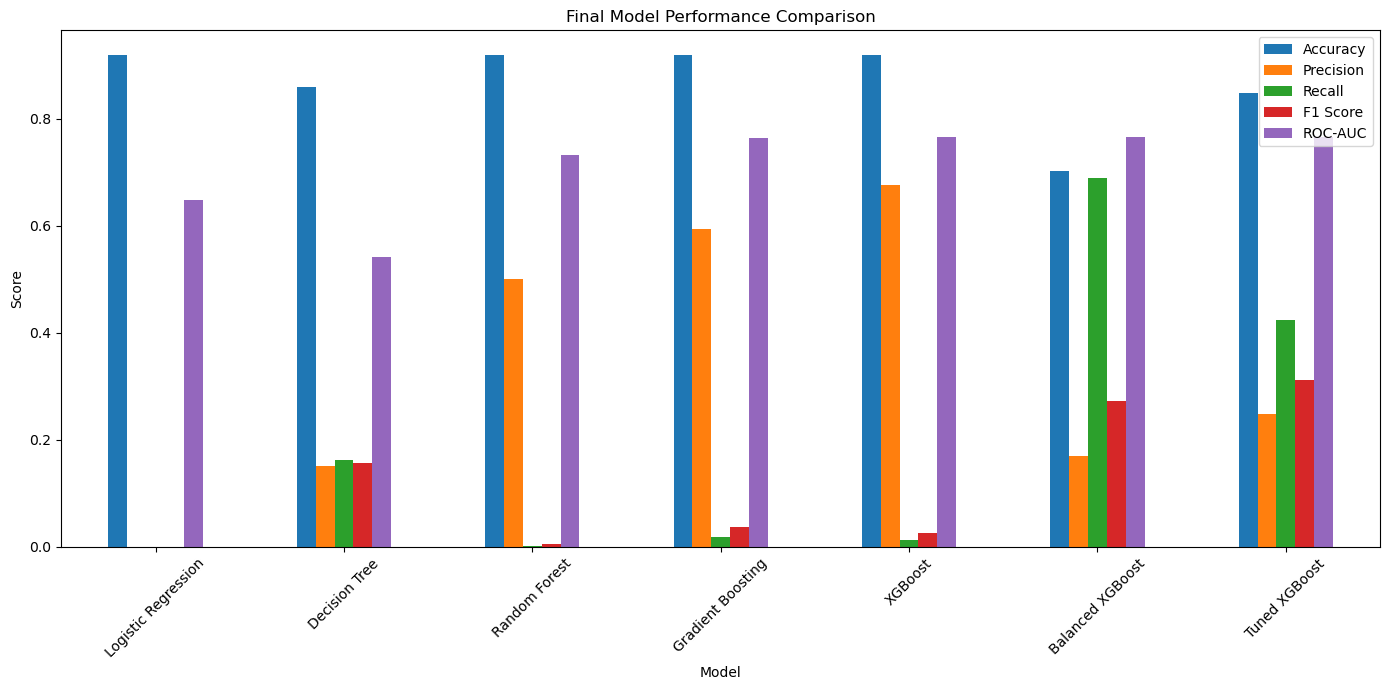

In [133]:
final_model_comparison.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Final Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### ROC Curve

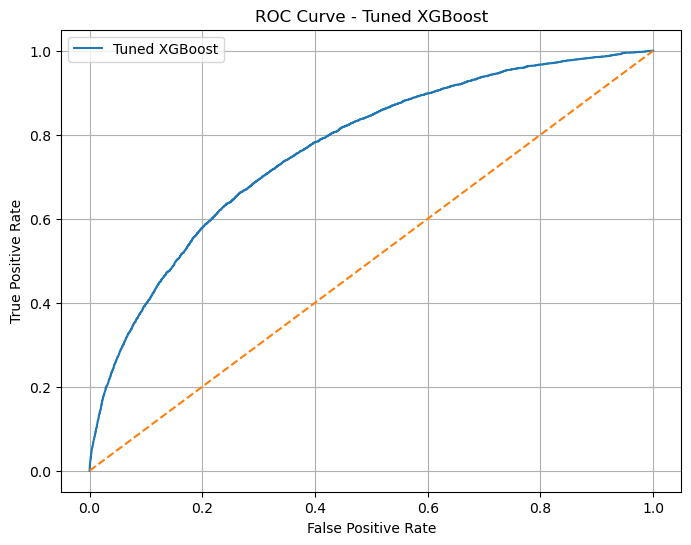

In [134]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve for Tuned XGBoost
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb_bal)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Tuned XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Tuned XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

#### Precision-Recall Curve

##### This is particularly useful for our project because the dataset is imbalanced and only about 8% of customers are defaulters.

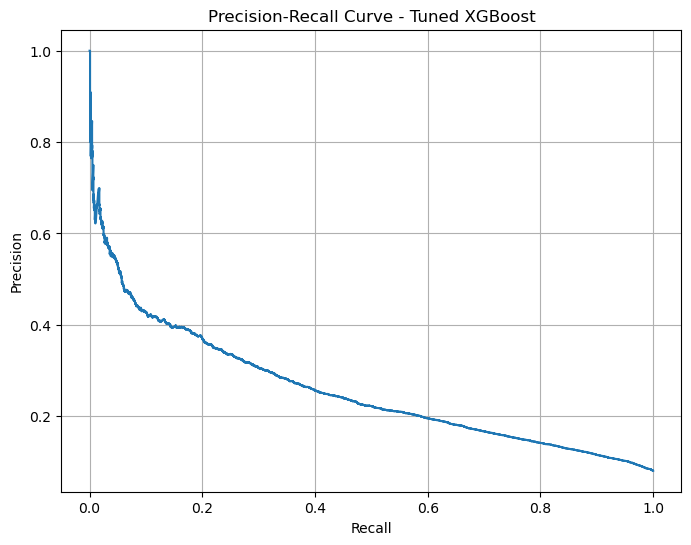

In [135]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb_bal
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)

plt.title('Precision-Recall Curve - Tuned XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

#### Model Evaluation and Graphical Analysis Conclusion

###### Seven classification approaches were evaluated for Home Loan Default Risk Management: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, Balanced XGBoost, and Tuned XGBoost.

###### The model comparison shows that accuracy alone is not sufficient for this project because the target variable is highly imbalanced, with only **8.07% of customers belonging to the default class**. Some models achieved around 92% accuracy while identifying very few actual defaulters.

###### The original XGBoost model achieved a **ROC-AUC of 0.7659** and a precision of **67.74%**, but its recall was only **1.27%** at the default threshold of 0.50. To improve the identification of potential defaulters, class imbalance was addressed using `scale_pos_weight` in Balanced XGBoost. This increased recall substantially to **68.92%**, although precision decreased to **16.98%**.

###### Threshold tuning was then performed to obtain a more suitable balance between precision and recall. Among the tested thresholds, **0.65 produced the highest F1 Score of 31.25%**. At this threshold, the model achieved **84.94% accuracy, 24.75% precision, 42.40% recall, and 0.7655 ROC-AUC**.

###### The ROC curve demonstrates the model's ability to distinguish between default and non-default customers across different classification thresholds. The Precision-Recall curve further illustrates the trade-off between identifying more actual defaulters and controlling false-positive predictions.

###### Based on these evaluation results, the **Tuned XGBoost model with a 0.65 classification threshold** is selected as the final model for this project. The selected threshold provides a more balanced precision-recall trade-off than the default 0.50 threshold of Balanced XGBoost.

###### Overall, the analysis demonstrates that handling class imbalance and tuning the classification threshold are important for developing a useful home loan default prediction model.


### Feature Importance

In [136]:
# Calculate Feature Importance
# Get feature importance from the Balanced XGBoost model
feature_importance = xgb_balanced.feature_importances_

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top 20 features
feature_importance_df.head(20)

,Feature,Importance
27,num__EXT_SOURCE_2,0.074691
28,num__EXT_SOURCE_3,0.073390
89,num__EMPLOYMENT_YEARS,0.063945
159,cat__NAME_EDUCATION_TYPE_Higher education,0.044797
93,num__CREDIT_GOODS_RATIO,0.027880
26,num__EXT_SOURCE_1,0.026574
137,cat__CODE_GENDER_M,0.024708
105,num__PREV_TOTAL_DOWN_PAYMENT,0.022604
7,num__DAYS_EMPLOYED,0.020923
115,num__POS_CASH_AVG_DPD_DEF,0.019765


#### Conclusion-
##### The most influential features are:

###### EXT_SOURCE_2 — 7.47%
###### EXT_SOURCE_3 — 7.34%
###### EMPLOYMENT_YEARS — 6.39%
###### NAME_EDUCATION_TYPE_Higher education — 4.48%
###### CREDIT_GOODS_RATIO — 2.79%

### Feature Importance Graph

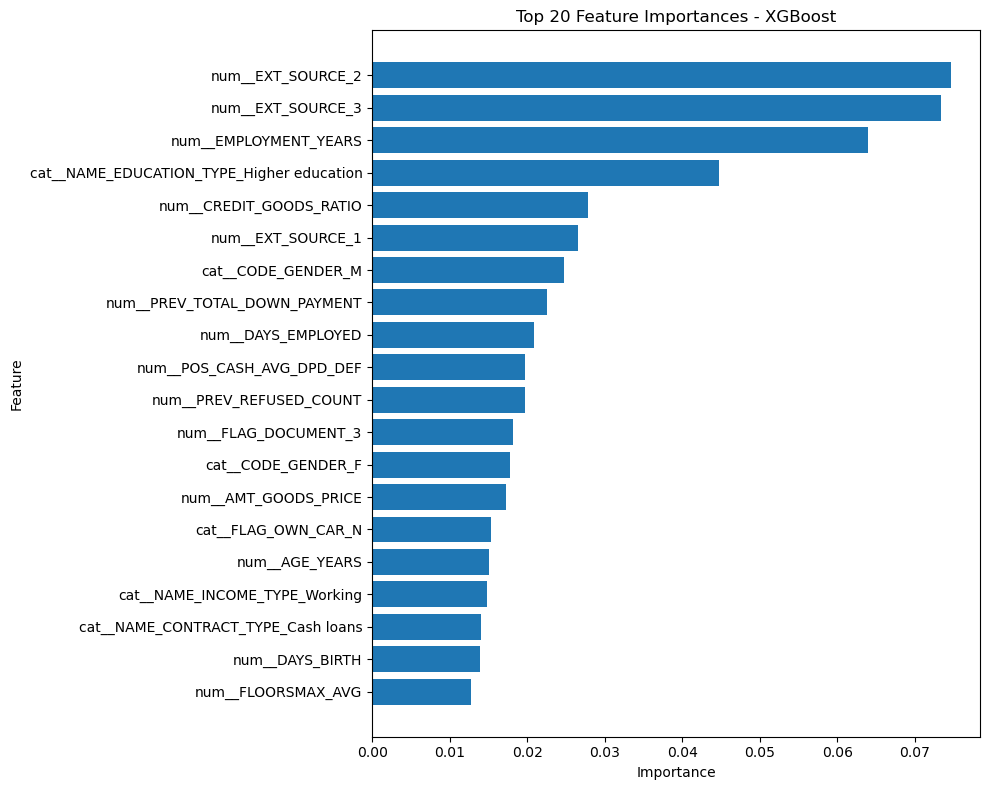

In [137]:
top_features = feature_importance_df.head(20).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 20 Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Feature Importance Conclusion

###### The feature importance analysis of the XGBoost model identifies the variables that contributed most to the model's predictions of home loan default risk.

###### The most influential features were **EXT_SOURCE_2 (7.47%)**, **EXT_SOURCE_3 (7.34%)**, and **EMPLOYMENT_YEARS (6.39%)**. Other important variables included **NAME_EDUCATION_TYPE_Higher education (4.48%)**, **CREDIT_GOODS_RATIO (2.79%)**, and **EXT_SOURCE_1 (2.66%)**.

###### The external source variables (`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`) collectively have substantial importance in the model. Employment duration, credit-to-goods ratio, education type, previous application information, and certain demographic and financial variables also contribute to the prediction.

###### The feature-importance results indicate that the model uses a combination of **external risk indicators, employment characteristics, financial ratios, education, previous credit history, and demographic information** when predicting default risk.

###### Feature importance shows which variables the model relied on most for prediction; it does not by itself establish that a feature causes loan default. These results can therefore be used to understand the model and support further business analysis.


### Risk Factors Identified

###### Based on the feature importance analysis and model evaluation, the following factors were identified as important predictors of home loan default risk:

##### 1. External Risk Indicators

####### `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` were among the most important features used by the model. These variables provide external information related to the applicant's credit or risk profile.

##### 2. Employment Duration

###### `EMPLOYMENT_YEARS` was one of the most influential engineered features. Employment history can provide information about the applicant's employment stability and financial situation.

##### 3. Credit-to-Goods Ratio

###### `CREDIT_GOODS_RATIO` was also an important predictor. A higher ratio indicates that the requested credit amount is relatively large compared with the value of the goods associated with the loan.

##### 4. Education

###### `NAME_EDUCATION_TYPE_Higher education` was among the important categorical features used by the model. Education level may capture differences in applicant characteristics and financial profiles.

##### 5. Previous Credit/Application History

###### Features such as `PREV_TOTAL_DOWN_PAYMENT`, `PREV_REFUSED_COUNT`, and `POS_CASH_AVG_DPD_DEF` contributed to the model's predictions. These variables provide information about previous applications, previous refusals, and repayment-related behaviour.

##### 6. Age and Employment Information

###### `AGE_YEARS`, `DAYS_BIRTH`, and `DAYS_EMPLOYED` were also among the important features. These variables provide information about the applicant's age and employment history.

##### 7. Financial and Asset Information

###### Variables such as `AMT_GOODS_PRICE` and other credit-related variables were also used by the model. These features help the model identify differences in applicants' financial and loan profiles.

##### Overall Risk Perspective

###### The model indicates that home loan default risk is influenced by a combination of **external risk indicators, employment history, credit characteristics, previous application behaviour, demographic information, and financial variables**.

###### These factors should be treated as **model-based risk indicators rather than direct causes of default**. Further validation and domain expertise would be required before using them as independent lending decisions.


### Report On Challenges Faced

#### Report on Challenges Faced

###### During the Home Loan Default Risk Management project, several challenges were encountered while working with the dataset and developing the prediction models. The following techniques were used to address these challenges.

##### 1. Large Dataset Size

###### The project consisted of multiple large datasets, including application, bureau, previous application, installments, POS cash balance, credit card balance, and bureau balance data.

###### **Challenge:** Working with multiple large CSV files required careful data handling and preprocessing.

###### **Technique Used:** The datasets were loaded and processed systematically, and the main application dataset was used as the primary modelling dataset.

###### **Reason:** This helped manage the large volume of data while maintaining a practical modelling workflow.

##### 2. Missing Values

###### Several features contained missing values.

###### **Challenge:** Missing values can cause errors during model training and reduce the quality of predictions.

###### **Technique Used:** Numerical features were handled using **median imputation**, while categorical features were handled using **most-frequent imputation**.

###### **Reason:** Median imputation is less affected by extreme values, while the most frequent category provides a simple way to fill missing categorical observations.

##### 3. Categorical Variables

###### The dataset contained several categorical variables such as education type, gender, income type, and contract type.

###### **Challenge:** Machine learning models require numerical input.

###### **Technique Used:** **One-Hot Encoding** was applied to categorical variables using `OneHotEncoder(handle_unknown='ignore')`.

###### **Reason:** One-hot encoding converts categorical values into numerical features while allowing previously unseen categories in the test data to be handled safely.

##### 4. Class Imbalance

###### The target variable was highly imbalanced.

###### The dataset contained approximately **91.93% non-default customers and 8.07% default customers**.

###### **Challenge:** A model could achieve high accuracy by predicting mostly non-default customers while failing to identify actual defaulters.

###### **Technique Used:** Class imbalance was addressed using **`scale_pos_weight` in XGBoost**.

###### **Reason:** This gives greater importance to the minority default class and helps the model identify more potential defaulters.

##### 5. Low Recall at the Default Classification Threshold

###### The original XGBoost model achieved high precision but identified very few actual defaulters at the default threshold of 0.50.

###### **Challenge:** Missing actual defaulters is an important concern in a loan-risk prediction problem.

###### **Technique Used:** **Classification threshold tuning** was performed using multiple thresholds from 0.20 to 0.70.

###### **Reason:** Changing the threshold allows the balance between precision and recall to be adjusted according to the requirements of the problem.

###### A threshold of **0.65** produced the highest F1 Score among the tested thresholds.

##### 6. Feature Engineering

###### The original dataset contained raw variables that could be transformed into more meaningful financial and demographic indicators.

###### **Technique Used:** New features such as `AGE_YEARS`, `EMPLOYMENT_YEARS`, `INCOME_CREDIT_RATIO`, `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `CREDIT_GOODS_RATIO`, and `INCOME_PER_FAMILY_MEMBER` were created.

###### **Reason:** Derived features can provide additional information to the model and help represent relationships between important financial variables.

##### 7. Model Selection

###### Several machine learning algorithms produced different results across accuracy, precision, recall, F1 Score, and ROC-AUC.

###### **Challenge:** Accuracy alone was not sufficient because of the class imbalance.

###### **Technique Used:** Multiple evaluation metrics were compared, including **Precision, Recall, F1 Score, and ROC-AUC**, along with confusion matrices.

###### **Reason:** These metrics provide a more complete understanding of how effectively the models identify default cases.

#### Overall Challenge Summary

###### The major challenges in this project were **large datasets, missing values, categorical variables, class imbalance, low minority-class recall, and selecting appropriate evaluation metrics**.

###### The use of preprocessing pipelines, feature engineering, XGBoost class weighting, threshold tuning, and multiple evaluation metrics helped address these challenges and develop a more useful home loan default risk prediction model.



####  Business Recommendations

###### Based on the results of the Home Loan Default Risk Management project, the following recommendations can be considered:

###### 1. **Use risk-based screening:** Applications identified as higher risk by the model can be subjected to additional verification or review.

###### 2. **Focus on potential defaulters:** Since the dataset is highly imbalanced, the model should be used to identify customers who may require additional assessment rather than relying only on overall accuracy.

###### 3. **Use an appropriate classification threshold:** The tuned threshold of **0.65** provided a better precision-recall balance than the default threshold of 0.50 in the tested results.

###### 4. **Review financial and credit indicators:** Features related to external risk indicators, employment history, credit characteristics, and previous application behaviour were important to the model and can be considered during risk assessment.

###### 5. **Combine model predictions with human review:** Model predictions should support, rather than completely replace, appropriate credit assessment and verification processes.

###### 6. **Monitor model performance:** The model should be periodically evaluated using precision, recall, F1 Score, ROC-AUC, and confusion matrices to ensure that its performance remains suitable for the intended application.

###### 7. **Validate before deployment:** Before using the model in a real lending environment, it should be tested on newer data and evaluated for stability, data quality, and suitability for the institution's lending policies.


###  Final Project Conclusion

###### The Home Loan Default Risk Management project was developed to predict the likelihood of loan default using customer demographic, financial, employment, credit, and previous application information.

###### The data was cleaned and preprocessed using appropriate techniques for missing values and categorical variables. Feature engineering was also performed to create additional indicators such as age, employment duration, income-to-credit ratios, credit-to-goods ratio, and income per family member.

###### Multiple classification algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, Balanced XGBoost, and Tuned XGBoost. Model performance was evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC, confusion matrices, ROC curves, and Precision-Recall curves.

###### Because the dataset contained only **8.07% default cases**, class imbalance was an important challenge. Balanced XGBoost substantially increased recall for the default class. Classification threshold tuning was then performed to obtain a better balance between precision and recall. Among the tested thresholds, **0.65 produced the highest F1 Score of 31.25%**.

###### The final selected approach was **Balanced XGBoost with a classification threshold of 0.65**, which achieved **84.94% accuracy, 24.75% precision, 42.40% recall, 31.25% F1 Score, and 0.7655**


#### Save the final model

In [138]:
import joblib

joblib.dump(xgb_balanced, 'home_loan_xgboost_model.pkl')

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.


In [139]:
joblib.dump(xgb_balanced, 'home_loan_xgboost_model.pkl')

['home_loan_xgboost_model.pkl']

In [140]:
import joblib

final_model = {
    'model': xgb_balanced,
    'threshold': 0.65
}

joblib.dump(final_model, 'home_loan_final_model.pkl')

print("Final model and threshold saved successfully.")

Final model and threshold saved successfully.


In [141]:
import joblib

joblib.dump(preprocessor, 'home_loan_preprocessor.pkl')

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [142]:
import joblib

# Load the saved model
loaded_model_data = joblib.load('home_loan_final_model.pkl')

# Load the saved preprocessor
loaded_preprocessor = joblib.load('home_loan_preprocessor.pkl')

# Extract model and threshold
loaded_model = loaded_model_data['model']
loaded_threshold = loaded_model_data['threshold']

print("Model loaded successfully.")
print("Preprocessor loaded successfully.")
print("Classification threshold:", loaded_threshold)

Model loaded successfully.
Preprocessor loaded successfully.
Classification threshold: 0.65
